In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np
from rdkit import Chem
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df = pd.read_csv('Clozapine_dataset.csv')
print(f"Original dataset size: {len(df)}")

# ============================================================================
# PART 0: LOAD DATA + ONE SHARED SPLIT (used by BOTH models below)
# ============================================================================

all_idx = np.arange(len(df))

idx_train, idx_temp = train_test_split(all_idx, test_size=0.30, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

print(f"Shared split -> Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

c:\Users\Arefeh\anaconda3\envs\pyphi-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original dataset size: 684
Shared split -> Train: 478 | Val: 103 | Test: 103


In [2]:
import hashlib
idx_signature = hashlib.md5(np.concatenate([idx_train, idx_val, idx_test]).tobytes()).hexdigest()
print(f"Split signature: {idx_signature}")

Split signature: b89e68489e42613b1923f1ca46aacbd1


In [3]:
# ============================================================================
# PART 1: MORDRED MODEL (PURE NN, no Van't Hoff) — split reused instead of re-split
# ============================================================================
act_func_map = {'Tanh': nn.Tanh, 'ReLU': nn.ReLU, 'Sigmoid': nn.Sigmoid, 'ELU': nn.ELU}

def initialize_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

def generate_MLP(n_input, hidden_layers, n_out, dropout, act_func):
    if len(hidden_layers) == 0:
        return nn.Sequential(nn.Linear(n_input, n_out), nn.Dropout(dropout))
    sizes = [n_input] + hidden_layers + [n_out]
    layers = []
    for i in range(len(sizes) - 1):
        layers += [nn.Linear(sizes[i], sizes[i + 1]), nn.Dropout(dropout), act_func()]
    return nn.Sequential(*layers[:-1])

from mordred import Calculator
from mordred import (
    SLogP, TopoPSA, HydrogenBond, McGowanVolume,
    Polarizability, Weight, LogS, Lipinski,
    MoeType, CPSA, RotatableBond, RingCount,
    Aromatic, KappaShapeIndex, Constitutional, EState,
    BCUT, VdwVolumeABC, TopologicalIndex, ZagrebIndex,
    ABCIndex, AcidBase, BondCount, CarbonTypes, Chi,
    EccentricConnectivityIndex, TopologicalCharge
)

calc = Calculator([
    SLogP, TopoPSA, HydrogenBond, McGowanVolume,
    Polarizability, Weight, LogS, Lipinski,
    MoeType, CPSA, RotatableBond, RingCount,
    Aromatic, KappaShapeIndex, Constitutional, EState,
    BCUT, VdwVolumeABC, TopologicalIndex, ZagrebIndex,
    ABCIndex, AcidBase, BondCount, CarbonTypes, Chi,
    EccentricConnectivityIndex, TopologicalCharge
], ignore_3D=True)

def smiles_to_mordred(smiles):
    if pd.isna(smiles) or smiles == '':
        return np.zeros(len(calc.descriptors))
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(len(calc.descriptors))
    result = calc(mol)
    values = [float(v) if isinstance(v, (int, float)) else 0.0 for v in result]
    return np.array(values)

fp_solvent1 = np.vstack(df['SMILES_1'].apply(smiles_to_mordred))
fp_solvent2 = np.vstack(df['SMILES_2'].apply(smiles_to_mordred))

x1 = df['comp_1'].values.reshape(-1, 1)
T = df['Temperature (K)'].values.reshape(-1, 1)
X_fp = np.hstack([fp_solvent1, fp_solvent2])
Y = df['LogS'].values.reshape(-1, 1)

print(f"X_fp shape : {X_fp.shape}")
print(f"x1 shape   : {x1.shape}")
print(f"T shape    : {T.shape}")
print(f"Y shape    : {Y.shape}")

class SolubilityPureNNModel(nn.Module):
    """
    Pure data-driven architecture (no Van't Hoff constraint):
    1. Fingerprint branch  : MLP(X_fp) -> fp_emb
    2. Composition branch  : MLP(x1)   -> comp_emb
    3. Temperature branch  : MLP(T)    -> temp_emb   (T is scaled, just another input)
    4. Fusion + output head: MLP([fp_emb, comp_emb, temp_emb]) -> LogS  (direct regression)
    """
    def __init__(
        self,
        n_fp_features=1362, fp_emb_hidden_layers=None, fp_emb_dropout=0.2,
        fp_emb_actfunc='Tanh', fp_emb_size=64,
        n_comp_features=1, comp_emb_hidden_layers=None, comp_emb_dropout=0.1,
        comp_emb_actfunc='Tanh', comp_emb_size=16,
        n_temp_features=1, temp_emb_hidden_layers=None, temp_emb_dropout=0.1,
        temp_emb_actfunc='Tanh', temp_emb_size=16,
        out_hidden_layers=None, out_dropout=0.1, out_actfunc='Tanh',
    ):
        super().__init__()
        if fp_emb_hidden_layers is None: fp_emb_hidden_layers = [512, 256, 128]
        if comp_emb_hidden_layers is None: comp_emb_hidden_layers = [16, 16]
        if temp_emb_hidden_layers is None: temp_emb_hidden_layers = [16, 16]
        if out_hidden_layers is None: out_hidden_layers = [32]

        self.fp_branch = generate_MLP(n_fp_features, fp_emb_hidden_layers, fp_emb_size,
                                       fp_emb_dropout, act_func_map[fp_emb_actfunc])
        self.comp_branch = generate_MLP(n_comp_features, comp_emb_hidden_layers, comp_emb_size,
                                         comp_emb_dropout, act_func_map[comp_emb_actfunc])
        self.temp_branch = generate_MLP(n_temp_features, temp_emb_hidden_layers, temp_emb_size,
                                         temp_emb_dropout, act_func_map[temp_emb_actfunc])
        fusion_size = fp_emb_size + comp_emb_size + temp_emb_size
        self.out_head = generate_MLP(fusion_size, out_hidden_layers, 1,
                                      out_dropout, act_func_map[out_actfunc])
        self.apply(initialize_weights)

    def forward(self, X_fp, x1, T):
        fp_emb = self.fp_branch(X_fp)
        comp_emb = self.comp_branch(x1)
        temp_emb = self.temp_branch(T)
        fused = torch.cat([fp_emb, comp_emb, temp_emb], dim=1)
        return self.out_head(fused)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def reset_parameters(self):
        self.apply(initialize_weights)

X_fp shape : (684, 1362)
x1 shape   : (684, 1)
T shape    : (684, 1)
Y shape    : (684, 1)


In [4]:

# ── Scaling (fit on full data, same as your original sample) ───────────────
scaler_fp = StandardScaler()
X_fp_scaled = scaler_fp.fit_transform(X_fp)

scaler_comp = StandardScaler()
x1_scaled = scaler_comp.fit_transform(x1)

scaler_temp = StandardScaler()
T_scaled = scaler_temp.fit_transform(T)

X_fp_train, x1_train, T_train, Y_train = X_fp_scaled[idx_train], x1_scaled[idx_train], T_scaled[idx_train], Y[idx_train]
X_fp_val,   x1_val,   T_val,   Y_val   = X_fp_scaled[idx_val],   x1_scaled[idx_val],   T_scaled[idx_val],   Y[idx_val]
X_fp_test,  x1_test,  T_test,  Y_test  = X_fp_scaled[idx_test],  x1_scaled[idx_test],  T_scaled[idx_test],  Y[idx_test]

print(f"Train: {len(X_fp_train)} | Val: {len(X_fp_val)} | Test: {len(X_fp_test)}")

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(to_t, [X_fp_train, x1_train, T_train, Y_train])
X_fp_val_t,   x1_val_t,   T_val_t,   Y_val_t   = map(to_t, [X_fp_val,   x1_val,   T_val,   Y_val])
X_fp_test_t,  x1_test_t,  T_test_t,  Y_test_t  = map(to_t, [X_fp_test,  x1_test,  T_test,  Y_test])

train_ds = TensorDataset(X_fp_train_t, x1_train_t, T_train_t, Y_train_t)
val_ds   = TensorDataset(X_fp_val_t,   x1_val_t,   T_val_t,   Y_val_t)
test_ds  = TensorDataset(X_fp_test_t,  x1_test_t,  T_test_t,  Y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=len(val_ds),   shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=len(test_ds),  shuffle=False)

mordred_model = SolubilityPureNNModel(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    n_temp_features=1, temp_emb_hidden_layers=[16, 16], temp_emb_dropout=0.1, temp_emb_actfunc='Tanh', temp_emb_size=16,
    out_hidden_layers=[32], out_dropout=0.1, out_actfunc='Tanh',
)
print(f"Total trainable parameters: {mordred_model.count_parameters()}")

optimizer = torch.optim.Adam(mordred_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss, patience_counter, best_weights = float('inf'), 0, None
train_losses, val_losses = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader:
        optimizer.zero_grad()
        Y_pred = mordred_model(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds)

    mordred_model.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader:
            epoch_val_loss = criterion(mordred_model(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_weights = {k: v.clone() for k, v in mordred_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model.load_state_dict(best_weights)
print(f"\nBest val loss: {best_val_loss:.4f}")

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    return r2, rmse, mae

mordred_model.eval()
with torch.no_grad():
    Y_pred_train_mordred = mordred_model(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val_mordred   = mordred_model(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test_mordred  = mordred_model(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np, Y_val_np, Y_test_np = Y_train_t.numpy().flatten(), Y_val_t.numpy().flatten(), Y_test_t.numpy().flatten()

r2_train_m, rmse_train_m, mae_train_m = get_metrics(Y_train_np, Y_pred_train_mordred)
r2_val_m, rmse_val_m, mae_val_m = get_metrics(Y_val_np, Y_pred_val_mordred)
r2_test_m, rmse_test_m, mae_test_m = get_metrics(Y_test_np, Y_pred_test_mordred)

print(f"\n[Mordred] Train | R²={r2_train_m:.4f} RMSE={rmse_train_m:.4f} MAE={mae_train_m:.4f}")
print(f"[Mordred] Val   | R²={r2_val_m:.4f} RMSE={rmse_val_m:.4f} MAE={mae_val_m:.4f}")
print(f"[Mordred] Test  | R²={r2_test_m:.4f} RMSE={rmse_test_m:.4f} MAE={mae_test_m:.4f}")

Train: 478 | Val: 103 | Test: 103
Total trainable parameters: 874625
Epoch   50 | Train: 0.1733 | Val: 0.0471
Epoch  100 | Train: 0.1265 | Val: 0.0241
Epoch  150 | Train: 0.1411 | Val: 0.0142
Epoch  200 | Train: 0.1404 | Val: 0.0120
Early stopping at epoch 222

Best val loss: 0.0081

[Mordred] Train | R²=0.9877 RMSE=0.1028 MAE=0.0667
[Mordred] Val   | R²=0.9891 RMSE=0.0901 MAE=0.0659
[Mordred] Test  | R²=0.9795 RMSE=0.1410 MAE=0.0851


In [5]:
# ── Save model weights + scalers + architecture config together ────────────
import pickle

torch.save({
    'model_state_dict': mordred_model.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'n_temp_features': 1, 'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'Tanh', 'temp_emb_size': 16,
        'out_hidden_layers': [32], 'out_dropout': 0.1, 'out_actfunc': 'Tanh',
    }
}, 'mordred_pure_nn_random_model.pt')

with open('mordred_pure_nn_random_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp, 'scaler_comp': scaler_comp, 'scaler_temp': scaler_temp}, f)

print("Saved model to 'mordred_pure_nn_random_model.pt' and scalers to 'mordred_pure_nn_random_scalers.pkl'")

Saved model to 'mordred_pure_nn_random_model.pt' and scalers to 'mordred_pure_nn_random_scalers.pkl'


In [6]:
# ============================================================================
# Load the model and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load model + scalers (no training required) ─────────────────────────────
checkpoint = torch.load('mordred_pure_nn_random_model.pt')

mordred_pure_nn_model = SolubilityPureNNModel(**checkpoint['model_config'])
mordred_pure_nn_model.load_state_dict(checkpoint['model_state_dict'])
mordred_pure_nn_model.eval()

with open('mordred_pure_nn_random_scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)
scaler_fp = scalers['scaler_fp']
scaler_comp = scalers['scaler_comp']
scaler_temp = scalers['scaler_temp']

print("Loaded mordred_pure_nn_random_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_pure_nn_random_model and scalers — ready for inference/plotting, no training needed.


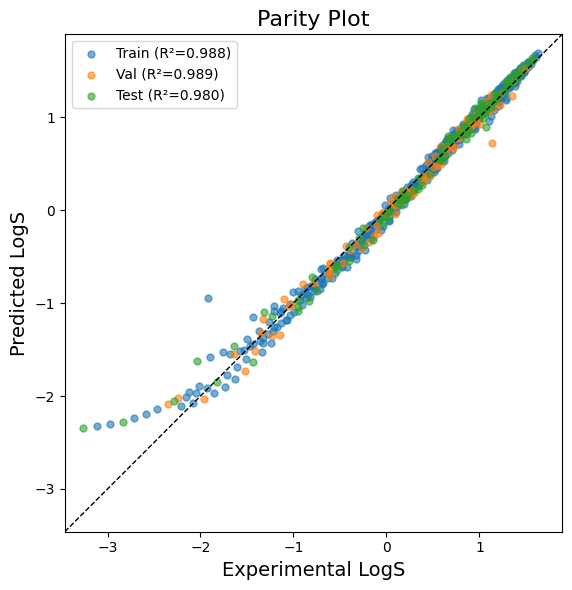

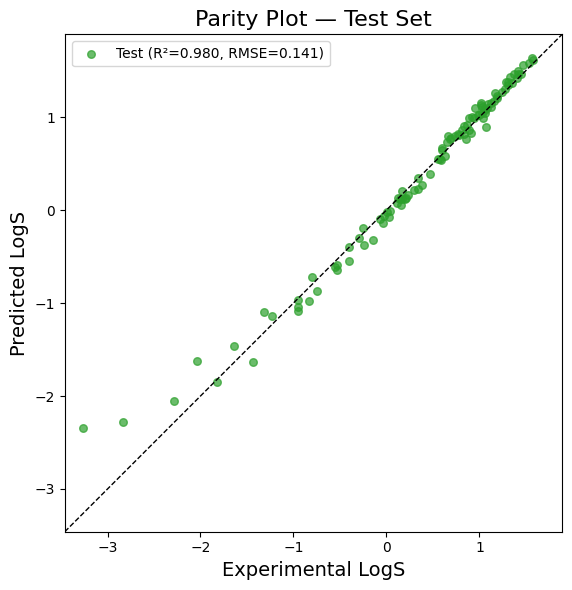

In [7]:
import matplotlib.pyplot as plt

# ── Rebuild scaled features using the LOADED scalers (transform only) ──────
X_fp_scaled = scaler_fp.transform(X_fp)
x1_scaled   = scaler_comp.transform(x1)
T_scaled    = scaler_temp.transform(T)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(to_t, [X_fp_scaled[idx_train], x1_scaled[idx_train], T_scaled[idx_train], Y[idx_train]])
X_fp_val_t,   x1_val_t,   T_val_t,   Y_val_t   = map(to_t, [X_fp_scaled[idx_val],   x1_scaled[idx_val],   T_scaled[idx_val],   Y[idx_val]])
X_fp_test_t,  x1_test_t,  T_test_t,  Y_test_t  = map(to_t, [X_fp_scaled[idx_test],  x1_scaled[idx_test],  T_scaled[idx_test],  Y[idx_test]])

# ── Get predictions ──────────────────────────────────────────────────────
mordred_pure_nn_model.eval()
with torch.no_grad():
    Y_pred_train = mordred_pure_nn_model(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val   = mordred_pure_nn_model(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test  = mordred_pure_nn_model(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np = Y_train_t.numpy().flatten()
Y_val_np   = Y_val_t.numpy().flatten()
Y_test_np  = Y_test_t.numpy().flatten()

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(Y_train_np, Y_pred_train)
r2_val,   rmse_val   = get_metrics(Y_val_np,   Y_pred_val)
r2_test,  rmse_test  = get_metrics(Y_test_np,  Y_pred_test)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([Y_train_np, Y_val_np, Y_test_np])
all_pred = np.concatenate([Y_pred_train, Y_pred_val, Y_pred_test])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_train_np, Y_pred_train, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(Y_val_np,   Y_pred_val,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(Y_test_np,  Y_pred_test,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_test_np, Y_pred_test, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot — Test Set', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

In [5]:
# ============================================================================
# PART 2: CHEMBERTA MODEL (PURE NN, no Van't Hoff) — split reused via Subset
# ============================================================================
class FineTunedChemBERTa(nn.Module):
    """
    1. ChemBERTa encoder (fine-tuned) -> fp1, fp2 -> concat -> mix_embedding -> mix_e
    2. Composition branch : MLP(comp_1)          -> comp_encoded
    3. Temperature branch : MLP(T, scaled)       -> temp_encoded
    4. Fusion             : concat([mix_e, comp_encoded, temp_encoded])
    5. Output head        : MLP(fused) -> LogS  (direct regression, no Van't Hoff)
    """
    def __init__(self, model_name, mix_emb_hidden_layers, mix_emb_dropout,
                 mix_emb_actfunc, mix_emb_size,
                 temp_emb_hidden_layers, temp_emb_dropout,
                 temp_emb_actfunc, temp_emb_size,
                 out_hidden_layers, out_dropout, out_actfunc):
        super().__init__()
        print(f"Loading ChemBERTa model: {model_name}")
        self.chemberta = AutoModel.from_pretrained(model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.mix_embedding = generate_MLP(
            n_input=1536, hidden_layers=mix_emb_hidden_layers, n_out=mix_emb_size,
            dropout=mix_emb_dropout, act_func=act_func_map[mix_emb_actfunc]
        )
        self.composition_encoder = generate_MLP(
            n_input=1, hidden_layers=[16, 8], n_out=16, dropout=0.1, act_func=nn.ReLU
        )
        self.temperature_encoder = generate_MLP(
            n_input=1, hidden_layers=temp_emb_hidden_layers, n_out=temp_emb_size,
            dropout=temp_emb_dropout, act_func=act_func_map[temp_emb_actfunc]
        )
        fusion_size = mix_emb_size + 16 + temp_emb_size
        self.out_head = generate_MLP(
            n_input=fusion_size, hidden_layers=out_hidden_layers, n_out=1,
            dropout=out_dropout, act_func=act_func_map[out_actfunc]
        )
        self.apply(initialize_weights)

    def encode_smiles(self, smiles_list):
        tokens = self.tokenizer(
            smiles_list, return_tensors="pt", padding=True, truncation=True,
            max_length=256, add_special_tokens=True
        ).to(next(self.chemberta.parameters()).device)
        outputs = self.chemberta(**tokens)
        attention_mask = tokens['attention_mask']
        hidden_states = outputs.last_hidden_state
        masked_hidden = hidden_states * attention_mask.unsqueeze(-1)
        embeddings = masked_hidden.sum(dim=1) / attention_mask.sum(dim=1).unsqueeze(-1)
        return embeddings

    def forward(self, smiles1_list, smiles2_list, comp1_list, T_list):
        fp1 = self.encode_smiles(smiles1_list)
        fp2 = self.encode_smiles(smiles2_list)
        fp_concat = torch.cat([fp1, fp2], dim=1)
        mix_e = self.mix_embedding(fp_concat)
        comp1 = comp1_list.reshape(-1, 1)
        comp_encoded = self.composition_encoder(comp1)
        T = T_list.reshape(-1, 1)
        temp_encoded = self.temperature_encoder(T)
        combined = torch.cat([mix_e, comp_encoded, temp_encoded], dim=1)
        LogS_pred = self.out_head(combined)
        return LogS_pred

    def unfreeze_chemberta(self, unfreeze_layers=-1):
        if unfreeze_layers == -1:
            for param in self.chemberta.parameters():
                param.requires_grad = True
            print("Unfroze all ChemBERTa layers")
        else:
            layers = list(self.chemberta.parameters())
            if unfreeze_layers > 0:
                for param in layers[-unfreeze_layers:]:
                    param.requires_grad = True
                print(f"Unfroze last {unfreeze_layers} layers of ChemBERTa")

    def freeze_chemberta(self):
        for param in self.chemberta.parameters():
            param.requires_grad = False
        print("Froze all ChemBERTa layers")

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

class SolubilityDataset(Dataset):
    """Temperature is scaled via an externally-fitted scaler (so the same
    scaler-per-split discipline used for Mordred applies here too)."""
    def __init__(self, df, temp_scaler):
        self.original_indices = df.index.values
        self.smiles1 = df['SMILES_1'].values
        self.smiles2 = df['SMILES_2'].values
        self.comp1 = df['comp_1'].values.astype(np.float32)
        T_raw = df['Temperature (K)'].values.astype(np.float32).reshape(-1, 1)
        self.y = df['LogS'].values.astype(np.float32)

        mask = ~(pd.isna(self.smiles1) | pd.isna(self.smiles2) |
                 pd.isna(self.comp1) | pd.isna(T_raw.flatten()) | pd.isna(self.y))

        self.original_indices = self.original_indices[mask]
        self.smiles1 = self.smiles1[mask]
        self.smiles2 = self.smiles2[mask]
        self.comp1 = self.comp1[mask]
        T_raw = T_raw[mask]
        self.y = self.y[mask]

        self.T = temp_scaler.transform(T_raw).astype(np.float32).flatten()

        print(f"Dataset size: {len(self.y)} samples")

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            'smiles1': self.smiles1[idx], 'smiles2': self.smiles2[idx],
            'comp1': torch.tensor(self.comp1[idx], dtype=torch.float32),
            'T': torch.tensor(self.T[idx], dtype=torch.float32),
            'y': torch.tensor(self.y[idx], dtype=torch.float32),
            'original_idx': self.original_indices[idx]
        }

def collate_fn(batch):
    smiles1 = [item['smiles1'] for item in batch]
    smiles2 = [item['smiles2'] for item in batch]
    comp1 = torch.stack([item['comp1'] for item in batch])
    T = torch.stack([item['T'] for item in batch])
    y = torch.stack([item['y'] for item in batch])
    original_idx = [item['original_idx'] for item in batch]
    return smiles1, smiles2, comp1, T, y, original_idx

def train_model(model, train_loader, val_loader, epochs, lr, device,
                stage_name="", unfreeze_after_epochs=None,
                best_val_loss=float('inf'), best_weights=None):
    if unfreeze_after_epochs is None:
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr * 0.1)

    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)

    train_losses, val_losses, val_r2_scores = [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for smiles1, smiles2, comp1, T, y, original_idx in train_loader:
            comp1, T, y = comp1.to(device), T.to(device), y.to(device)
            optimizer.zero_grad()
            predictions = model(smiles1, smiles2, comp1, T)
            loss = criterion(predictions.squeeze(), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for smiles1, smiles2, comp1, T, y, original_idx in val_loader:
                comp1, T, y = comp1.to(device), T.to(device), y.to(device)
                predictions = model(smiles1, smiles2, comp1, T)
                loss = criterion(predictions.squeeze(), y)
                val_loss += loss.item()
                all_preds.extend(predictions.squeeze().cpu().numpy())
                all_targets.extend(y.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        all_preds, all_targets = np.array(all_preds), np.array(all_targets)
        ss_res = np.sum((all_targets - all_preds) ** 2)
        ss_tot = np.sum((all_targets - np.mean(all_targets)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        val_r2_scores.append(r2)

        scheduler.step(avg_val_loss)

        # ── Best-checkpoint tracking (mirrors the Mordred model's logic) ──
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"{stage_name} Epoch {epoch+1}/{epochs}: "
                  f"Train Loss: {avg_train_loss:.4f}, "
                  f"Val Loss: {avg_val_loss:.4f}, "
                  f"Val R²: {r2:.4f}, "
                  f"Best Val: {best_val_loss:.4f}, "
                  f"LR: {current_lr:.6f}")
            print(f"  Pred range: [{all_preds.min():.2f}, {all_preds.max():.2f}], "
                  f"Target range: [{all_targets.min():.2f}, {all_targets.max():.2f}]")

        if unfreeze_after_epochs and epoch + 1 == unfreeze_after_epochs:
            print(f"\n*** Unfreezing ChemBERTa layers for stage {stage_name} ***")
            model.unfreeze_chemberta(unfreeze_layers=4)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr * 0.1)

    return train_losses, val_losses, val_r2_scores, best_val_loss, best_weights

In [7]:
# ── Dataset + SPLIT: reuse shared idx_train/idx_val/idx_test via Subset ────
scaler_temp_chem = StandardScaler().fit(df['Temperature (K)'].values.reshape(-1, 1))
chemberta_dataset = SolubilityDataset(df, temp_scaler=scaler_temp_chem)

chem_train_dataset = Subset(chemberta_dataset, idx_train)
chem_val_dataset   = Subset(chemberta_dataset, idx_val)
chem_test_dataset  = Subset(chemberta_dataset, idx_test)

batch_size = 32
chem_train_loader = DataLoader(chem_train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
chem_val_loader   = DataLoader(chem_val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
chem_test_loader  = DataLoader(chem_test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"[ChemBERTa] Train size: {len(chem_train_dataset)}, Val size: {len(chem_val_dataset)}, Test size: {len(chem_test_dataset)}")

chemberta_model = FineTunedChemBERTa(
    model_name="seyonec/ChemBERTa-zinc-base-v1",
    mix_emb_hidden_layers=[512, 256],
    mix_emb_dropout=0.3,
    mix_emb_actfunc='ReLU',
    mix_emb_size=128,
    temp_emb_hidden_layers=[16, 16],
    temp_emb_dropout=0.1,
    temp_emb_actfunc='ReLU',
    temp_emb_size=16,
    out_hidden_layers=[64, 32],
    out_dropout=0.2,
    out_actfunc='ReLU'
).to(DEVICE)
print(f"Total trainable parameters: {chemberta_model.count_parameters():,}")

print("\n" + "="*60)
print("STAGE 1: Training MLP heads only (ChemBERTa frozen)")
print("="*60)
chemberta_model.freeze_chemberta()
train_losses_1, val_losses_1, r2_scores_1, best_val_loss_c, best_weights_c = train_model(
    chemberta_model, chem_train_loader, chem_val_loader, epochs=50, lr=0.001,
    device=DEVICE, stage_name="Stage 1"
)

print("\n" + "="*60)
print("STAGE 2: Fine-tuning ChemBERTa (lower learning rate)")
print("="*60)
chemberta_model.unfreeze_chemberta(unfreeze_layers=4)
train_losses_2, val_losses_2, r2_scores_2, best_val_loss_c, best_weights_c = train_model(
    chemberta_model, chem_train_loader, chem_val_loader, epochs=30, lr=0.0001,
    device=DEVICE, stage_name="Stage 2",
    best_val_loss=best_val_loss_c, best_weights=best_weights_c   # carry over from Stage 1
)

chemberta_model.load_state_dict(best_weights_c)
print(f"\nLoaded best ChemBERTa checkpoint (val loss = {best_val_loss_c:.4f})")

print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET (ChemBERTa)")
print("="*60)
chemberta_model.eval()
test_preds_c, test_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_test_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_model(smiles1, smiles2, comp1, T)
        test_preds_c.extend(predictions.squeeze().cpu().numpy())
        test_targets_c.extend(y.numpy())

test_preds_c, test_targets_c = np.array(test_preds_c), np.array(test_targets_c)


Dataset size: 684 samples
[ChemBERTa] Train size: 478, Val size: 103, Test size: 103
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Total trainable parameters: 45,068,409

STAGE 1: Training MLP heads only (ChemBERTa frozen)
Froze all ChemBERTa layers
Stage 1 Epoch 10/50: Train Loss: 0.5503, Val Loss: 0.3726, Val R²: 0.5136, Best Val: 0.2191, LR: 0.001000
  Pred range: [-1.54, 0.80], Target range: [-2.35, 1.50]
Stage 1 Epoch 20/50: Train Loss: 0.4413, Val Loss: 0.1603, Val R²: 0.7855, Best Val: 0.1176, LR: 0.001000
  Pred range: [-1.64, 0.99], Target range: [-2.35, 1.50]
Stage 1 Epoch 30/50: Train Loss: 0.3526, Val Loss: 0.1277, Val R²: 0.8320, Best Val: 0.1063, LR: 0.000500
  Pred range: [-1.47, 1.05], Target range: [-2.35, 1.50]
Stage 1 Epoch 40/50: Train Loss: 0.3341, Val Loss: 0.1319, Val R²: 0.8243, Best Val: 0.1063, LR: 0.000250
  Pred range: [-1.57, 1.00], Target range: [-2.35, 1.50]
Stage 1 Epoch 50/50: Train Loss: 0.3133, Val Loss: 0.1323, Val R²: 0.8220, Best Val: 0.1

In [10]:
# ── Save ChemBERTa Pure NN (random split) model + config ────────────────────
torch.save({
    'model_state_dict': chemberta_model.state_dict(),
    'model_config': {
        'model_name': "seyonec/ChemBERTa-zinc-base-v1",
        'mix_emb_hidden_layers': [512, 256], 'mix_emb_dropout': 0.3, 'mix_emb_actfunc': 'ReLU', 'mix_emb_size': 128,
        'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'ReLU', 'temp_emb_size': 16,
        'out_hidden_layers': [64, 32], 'out_dropout': 0.2, 'out_actfunc': 'ReLU',
    }
}, 'chemberta_pure_nn_random_model.pt')

with open('chemberta_pure_nn_random_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_temp': scaler_temp_chem}, f)

print("Saved model to 'chemberta_pure_nn_random_model.pt' and scalers to 'chemberta_pure_nn_random_scalers.pkl'")

Saved model to 'chemberta_pure_nn_random_model.pt' and scalers to 'chemberta_pure_nn_random_scalers.pkl'


In [11]:
# ============================================================================
# Load ChemBERTa Pure NN (random split) model — no training required
# ============================================================================
import pickle

# ── Load ChemBERTa Pure NN (random split) model ────────────────────────────
checkpoint_chemberta_pure_nn = torch.load('chemberta_pure_nn_random_model.pt', map_location=DEVICE)

chemberta_pure_nn_model = FineTunedChemBERTa(**checkpoint_chemberta_pure_nn['model_config']).to(DEVICE)
chemberta_pure_nn_model.load_state_dict(checkpoint_chemberta_pure_nn['model_state_dict'])
chemberta_pure_nn_model.eval()

with open('chemberta_pure_nn_random_scalers.pkl', 'rb') as f:
    scalers_chem = pickle.load(f)
scaler_temp_chem_loaded = scalers_chem['scaler_temp']

print("Loaded chemberta_pure_nn_random_model and scalers — ready for inference/plotting, no training needed.")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_pure_nn_random_model and scalers — ready for inference/plotting, no training needed.


Dataset size: 684 samples


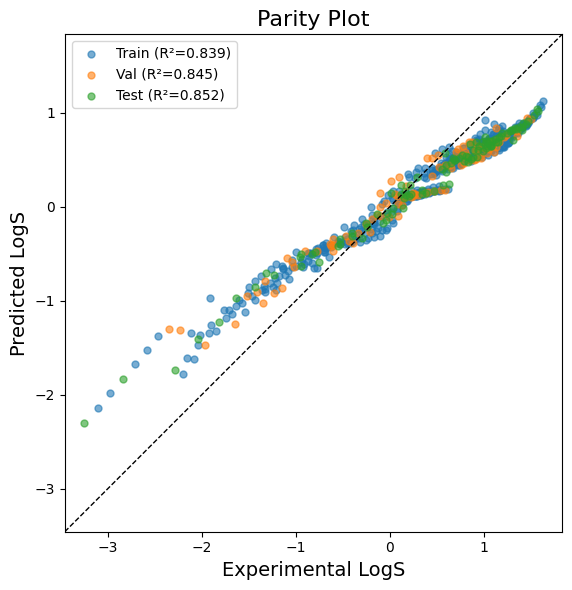

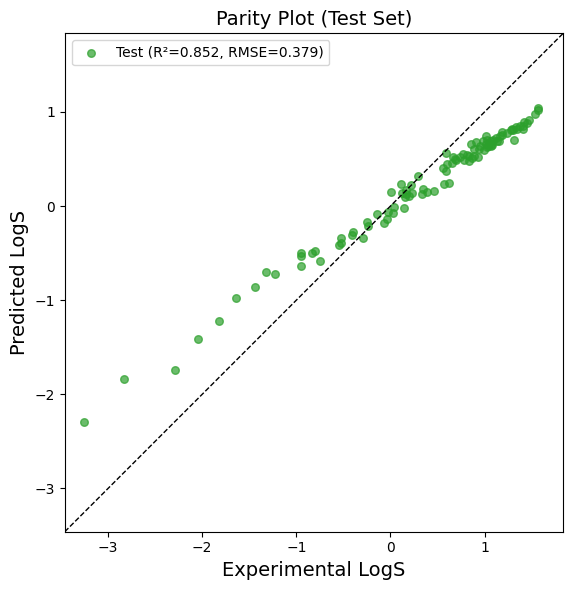


[ChemBERTa Pure NN] Train | R²=0.8395 RMSE=0.3715, MAE=0.3193
[ChemBERTa Pure NN] Val   | R²=0.8455 RMSE=0.3396, MAE=0.2828
[ChemBERTa Pure NN] Test  | R²=0.8523 RMSE=0.3788, MAE=0.3211


In [15]:
# ============================================================================
# Plotting for ChemBERTa Pure NN Model (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# ── Recreate dataset with the loaded temperature scaler ──────────────────
# The dataset needs the temperature scaler (same as used during training)
chemberta_dataset = SolubilityDataset(df, temp_scaler=scaler_temp_chem_loaded)

# Get the subsets using the same indices
chem_train_dataset = Subset(chemberta_dataset, idx_train)
chem_val_dataset   = Subset(chemberta_dataset, idx_val)
chem_test_dataset  = Subset(chemberta_dataset, idx_test)

# Create data loaders (no shuffling needed for predictions)
batch_size = 32
chem_train_loader = DataLoader(chem_train_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
chem_val_loader   = DataLoader(chem_val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
chem_test_loader  = DataLoader(chem_test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# ── Get predictions for all sets ──────────────────────────────────────────
chemberta_pure_nn_model.eval()

# Train set predictions
train_preds_c, train_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_train_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_pure_nn_model(smiles1, smiles2, comp1, T)
        train_preds_c.extend(predictions.squeeze().cpu().numpy())
        train_targets_c.extend(y.numpy())

# Validation set predictions
val_preds_c, val_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_val_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_pure_nn_model(smiles1, smiles2, comp1, T)
        val_preds_c.extend(predictions.squeeze().cpu().numpy())
        val_targets_c.extend(y.numpy())

# Test set predictions
test_preds_c, test_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_test_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_pure_nn_model(smiles1, smiles2, comp1, T)
        test_preds_c.extend(predictions.squeeze().cpu().numpy())
        test_targets_c.extend(y.numpy())

# Convert to numpy arrays
train_preds_c = np.array(train_preds_c)
train_targets_c = np.array(train_targets_c)
val_preds_c = np.array(val_preds_c)
val_targets_c = np.array(val_targets_c)
test_preds_c = np.array(test_preds_c)
test_targets_c = np.array(test_targets_c)

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(train_targets_c, train_preds_c)
r2_val,   rmse_val   = get_metrics(val_targets_c,   val_preds_c)
r2_test,  rmse_test  = get_metrics(test_targets_c,  test_preds_c)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([train_targets_c, val_targets_c, test_targets_c])
all_pred = np.concatenate([train_preds_c, val_preds_c, test_preds_c])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(train_targets_c, train_preds_c, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(val_targets_c,   val_preds_c,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(test_targets_c,  test_preds_c,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_targets_c, test_preds_c, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[ChemBERTa Pure NN] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(train_targets_c - train_preds_c)):.4f}")
print(f"[ChemBERTa Pure NN] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(val_targets_c - val_preds_c)):.4f}")
print(f"[ChemBERTa Pure NN] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(test_targets_c - test_preds_c)):.4f}")


COMPARISON — SAME TRAIN/TEST SPLIT FOR BOTH MODELS
Model       Set             R²      RMSE       MAE
ChemBERTa   Train       0.8395    0.3715    0.3193
ChemBERTa   Test        0.8523    0.3788    0.3211
Mordred     Train       0.9856    0.1114    0.0702
Mordred     Test        0.9786    0.1442    0.0826


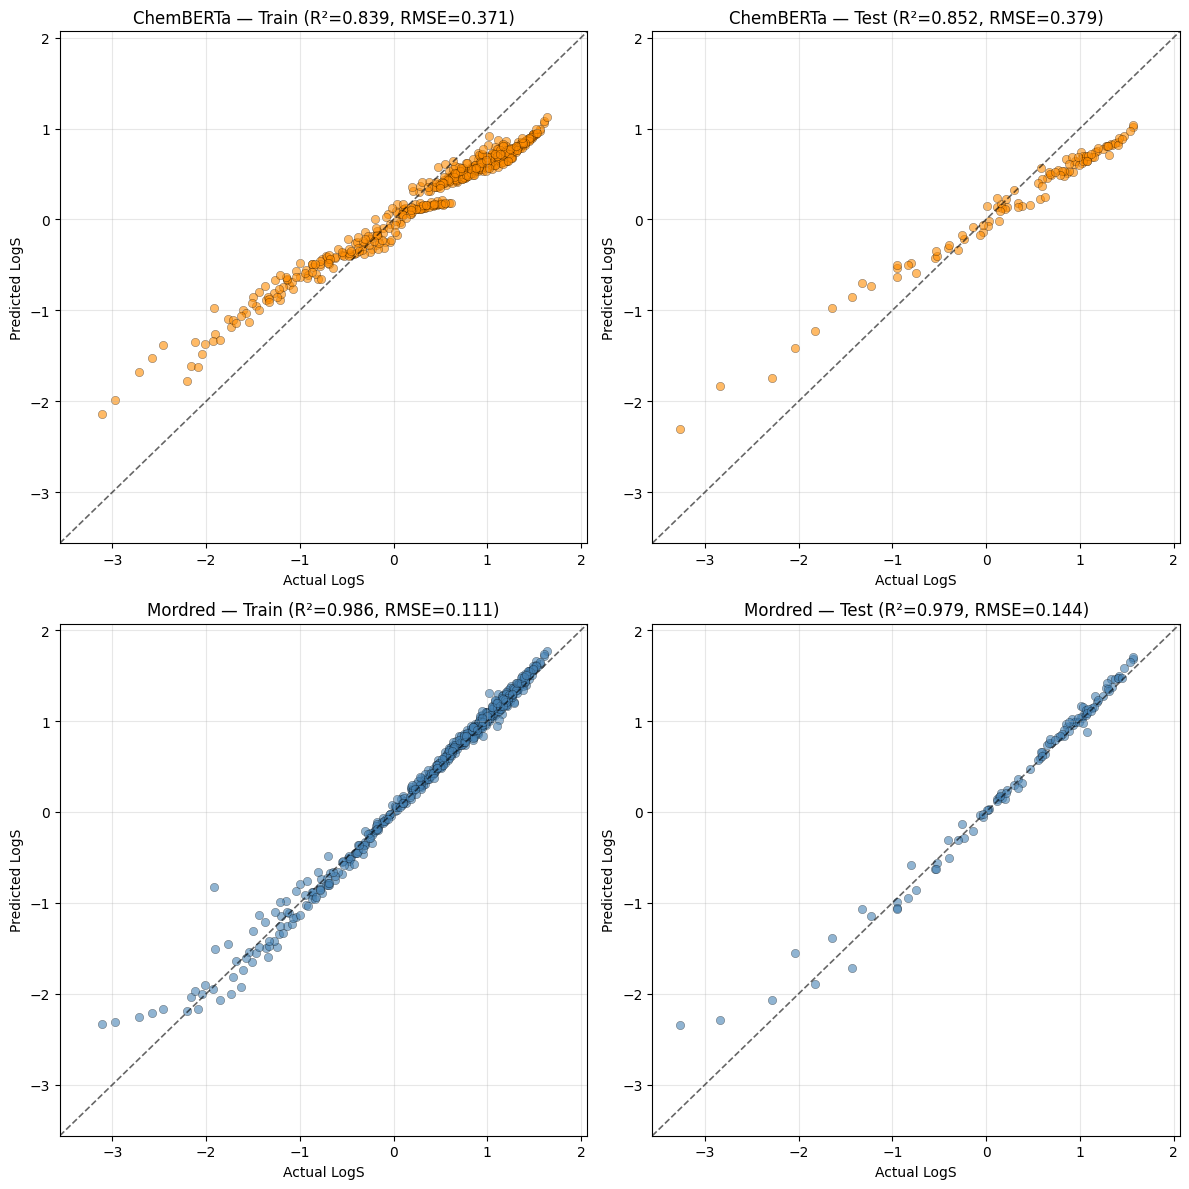

In [ ]:
# ============================================================================
# PART 3: SIDE-BY-SIDE COMPARISON — 2x2 GRID (rows: model, cols: train/test)
# ============================================================================

chemberta_model.eval()
train_preds_c, train_targets_c = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T, y, orig_idx in chem_train_loader:
        comp1, T = comp1.to(DEVICE), T.to(DEVICE)
        predictions = chemberta_model(smiles1, smiles2, comp1, T)
        train_preds_c.extend(predictions.squeeze().cpu().numpy())
        train_targets_c.extend(y.numpy())

train_preds_c, train_targets_c = np.array(train_preds_c), np.array(train_targets_c)
r2_train_c, rmse_train_c, mae_train_c = get_metrics(train_targets_c, train_preds_c)

print("\n" + "="*60)
print("COMPARISON — SAME TRAIN/TEST SPLIT FOR BOTH MODELS")
print("="*60)
print(f"{'Model':<12}{'Set':<8}{'R²':>10}{'RMSE':>10}{'MAE':>10}")
print(f"{'ChemBERTa':<12}{'Train':<8}{r2_train_c:>10.4f}{rmse_train_c:>10.4f}{mae_train_c:>10.4f}")
print(f"{'Mordred':<12}{'Train':<8}{r2_train_m:>10.4f}{rmse_train_m:>10.4f}{mae_train_m:>10.4f}")
print(f"{'Mordred':<12}{'Test':<8}{r2_test_m:>10.4f}{rmse_test_m:>10.4f}{mae_test_m:>10.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

all_vals = np.concatenate([train_targets_c, train_preds_c, test_targets_c, test_preds_c,
                           Y_train_np, Y_pred_train_mordred, Y_test_np, Y_pred_test_mordred])
lims = [all_vals.min() - 0.3, all_vals.max() + 0.3]

plot_specs = [
    (0, 0, train_targets_c, train_preds_c, 'darkorange', 'ChemBERTa', 'Train', r2_train_c, rmse_train_c),
    (0, 1, test_targets_c,  test_preds_c,  'darkorange', 'ChemBERTa', 'Test',  r2_c,        rmse_c),
    (1, 0, Y_train_np,      Y_pred_train_mordred, 'steelblue', 'Mordred', 'Train', r2_train_m, rmse_train_m),
    (1, 1, Y_test_np,       Y_pred_test_mordred,  'steelblue', 'Mordred', 'Test',  r2_test_m,  rmse_test_m),
]

for row, col, y_true, y_pred, color, model_name, set_name, r2, rmse in plot_specs:
    ax = axes[row, col]
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.3)
    ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.6)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual LogS')
    ax.set_ylabel('Predicted LogS')
    ax.set_title(f'{model_name} — {set_name} (R²={r2:.3f}, RMSE={rmse:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('mordred_vs_chemberta_comparison_2x2_pureNN.png', dpi=150)
plt.show()


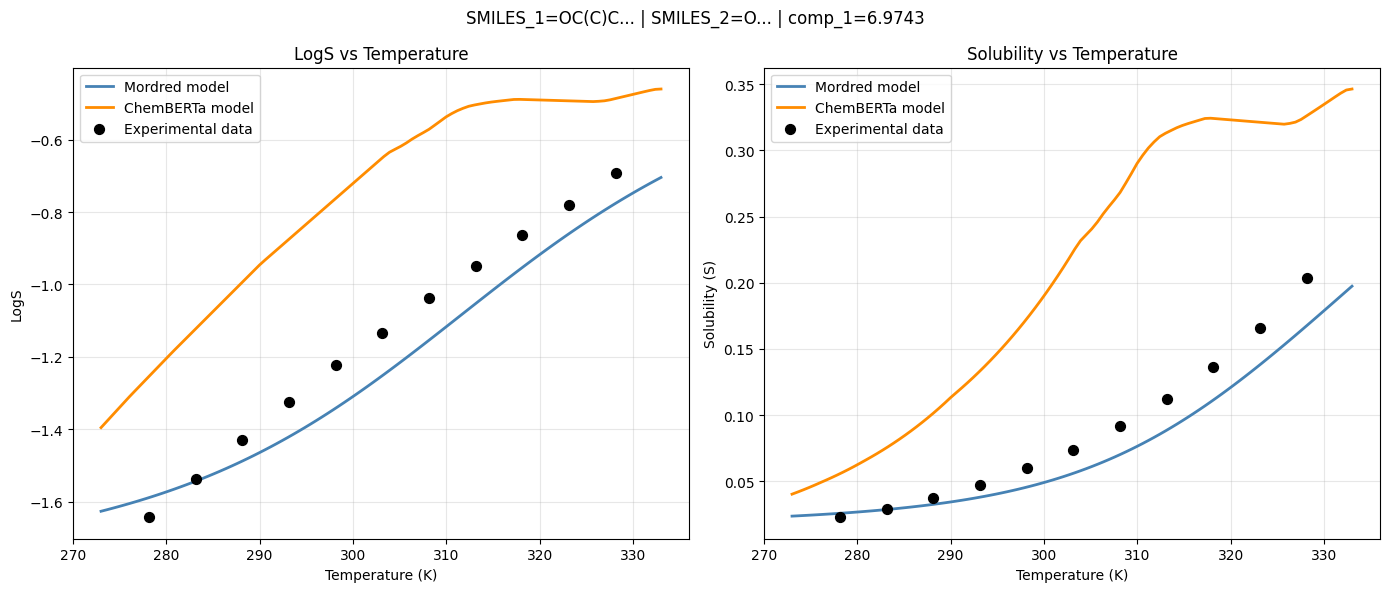

In [13]:
# ============================================================================
# PART 4: LogS and Solubility vs TEMPERATURE FOR A CHOSEN SOLVENT COMBINATION
# ============================================================================

def plot_solubility_vs_temperature(smiles_1, smiles_2, comp_1,
                                    T_min=270, T_max=330, n_points=100,
                                    models=('mordred', 'chemberta'),
                                    show_data=True, comp_tol=0.02):
    """
    Sweep T only (SMILES_1, SMILES_2, comp_1 fixed). Since there is no Van't Hoff
    constraint here, T must be scaled through the same scaler used at train time
    before being fed to the temperature branch of each model.
    """
    T_range = np.linspace(T_min, T_max, n_points)
    fig, (ax_log, ax_sol) = plt.subplots(1, 2, figsize=(14, 6))

    if 'mordred' in models:
        fp1 = smiles_to_mordred(smiles_1)
        fp2 = smiles_to_mordred(smiles_2)
        X_fp_combo = np.hstack([fp1, fp2]).reshape(1, -1)
        X_fp_combo_scaled = scaler_fp.transform(X_fp_combo)
        x1_combo_scaled = scaler_comp.transform(np.array([[comp_1]]))
        T_col_scaled = scaler_temp.transform(T_range.reshape(-1, 1))

        X_fp_rep = np.repeat(X_fp_combo_scaled, n_points, axis=0)
        x1_rep = np.repeat(x1_combo_scaled, n_points, axis=0)

        mordred_model.eval()
        with torch.no_grad():
            preds_m_logs = mordred_model(to_t(X_fp_rep), to_t(x1_rep), to_t(T_col_scaled)).numpy().flatten()
        preds_m_sol = 10 ** preds_m_logs

        ax_log.plot(T_range, preds_m_logs, color='steelblue', lw=2, label='Mordred model')
        ax_sol.plot(T_range, preds_m_sol, color='steelblue', lw=2, label='Mordred model')

    if 'chemberta' in models:
        chemberta_model.eval()
        smiles1_list = [smiles_1] * n_points
        smiles2_list = [smiles_2] * n_points
        comp1_t = torch.tensor([comp_1] * n_points, dtype=torch.float32).to(DEVICE)
        T_scaled_chem = scaler_temp_chem.transform(T_range.reshape(-1, 1)).flatten()
        T_t = torch.tensor(T_scaled_chem, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            preds_c_logs = chemberta_model(smiles1_list, smiles2_list, comp1_t, T_t).cpu().numpy().flatten()
        preds_c_sol = 10 ** preds_c_logs

        ax_log.plot(T_range, preds_c_logs, color='darkorange', lw=2, label='ChemBERTa model')
        ax_sol.plot(T_range, preds_c_sol, color='darkorange', lw=2, label='ChemBERTa model')

    if show_data:
        mask = (
            (df['SMILES_1'] == smiles_1) &
            (df['SMILES_2'] == smiles_2) &
            (np.isclose(df['comp_1'], comp_1, atol=comp_tol))
        )
        subset = df[mask]
        if len(subset) > 0:
            ax_log.scatter(subset['Temperature (K)'], subset['LogS'],
                           color='black', zorder=5, s=50, label='Experimental data')
            ax_sol.scatter(subset['Temperature (K)'], 10 ** subset['LogS'],
                           color='black', zorder=5, s=50, label='Experimental data')
        else:
            print(f"No experimental rows found matching comp_1≈{comp_1} (tol={comp_tol}) for this pair.")

    ax_log.set_xlabel('Temperature (K)'); ax_log.set_ylabel('LogS')
    ax_log.set_title('LogS vs Temperature'); ax_log.legend(); ax_log.grid(alpha=0.3)

    ax_sol.set_xlabel('Temperature (K)'); ax_sol.set_ylabel('Solubility (S)')
    ax_sol.set_title('Solubility vs Temperature'); ax_sol.legend(); ax_sol.grid(alpha=0.3)

    fig.suptitle(f'SMILES_1={smiles_1[:25]}... | SMILES_2={smiles_2[:25]}... | comp_1={comp_1}')
    plt.tight_layout()
    plt.show()

plot_solubility_vs_temperature(
    smiles_1="OC(C)C", smiles_2="O", comp_1=6.9743,
    T_min=273, T_max=333, models=('mordred', 'chemberta')
)

Temperature split -> Train: 528 | Val: 94 | Test: 62
Test temperatures: [278.15, 283.15]
[Temp split/Mordred] Train: 528 | Val: 94 | Test: 62
[Temp split/Mordred] Total trainable parameters: 874625
[Temp split/Mordred] Epoch   50 | Train: 0.1734 | Val: 0.0344
[Temp split/Mordred] Epoch  100 | Train: 0.1657 | Val: 0.0152
[Temp split/Mordred] Epoch  150 | Train: 0.1273 | Val: 0.0120
[Temp split/Mordred] Epoch  200 | Train: 0.1262 | Val: 0.0078
[Temp split/Mordred] Early stopping at epoch 229

[Temp split/Mordred] Best val loss: 0.0043
[Temp split/Mordred] Train | R²=0.9905 RMSE=0.0858 MAE=0.0458
[Temp split/Mordred] Test  | R²=0.9371 RMSE=0.2469 MAE=0.1830
Dataset size: 528 samples
Dataset size: 94 samples
Dataset size: 62 samples
[Temp split/ChemBERTa] Train: 528 | Val: 94 | Test: 62
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
[Temp split/ChemBERTa] Total trainable parameters: 45,068,409

[Temp split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)
Froze all ChemBERTa la

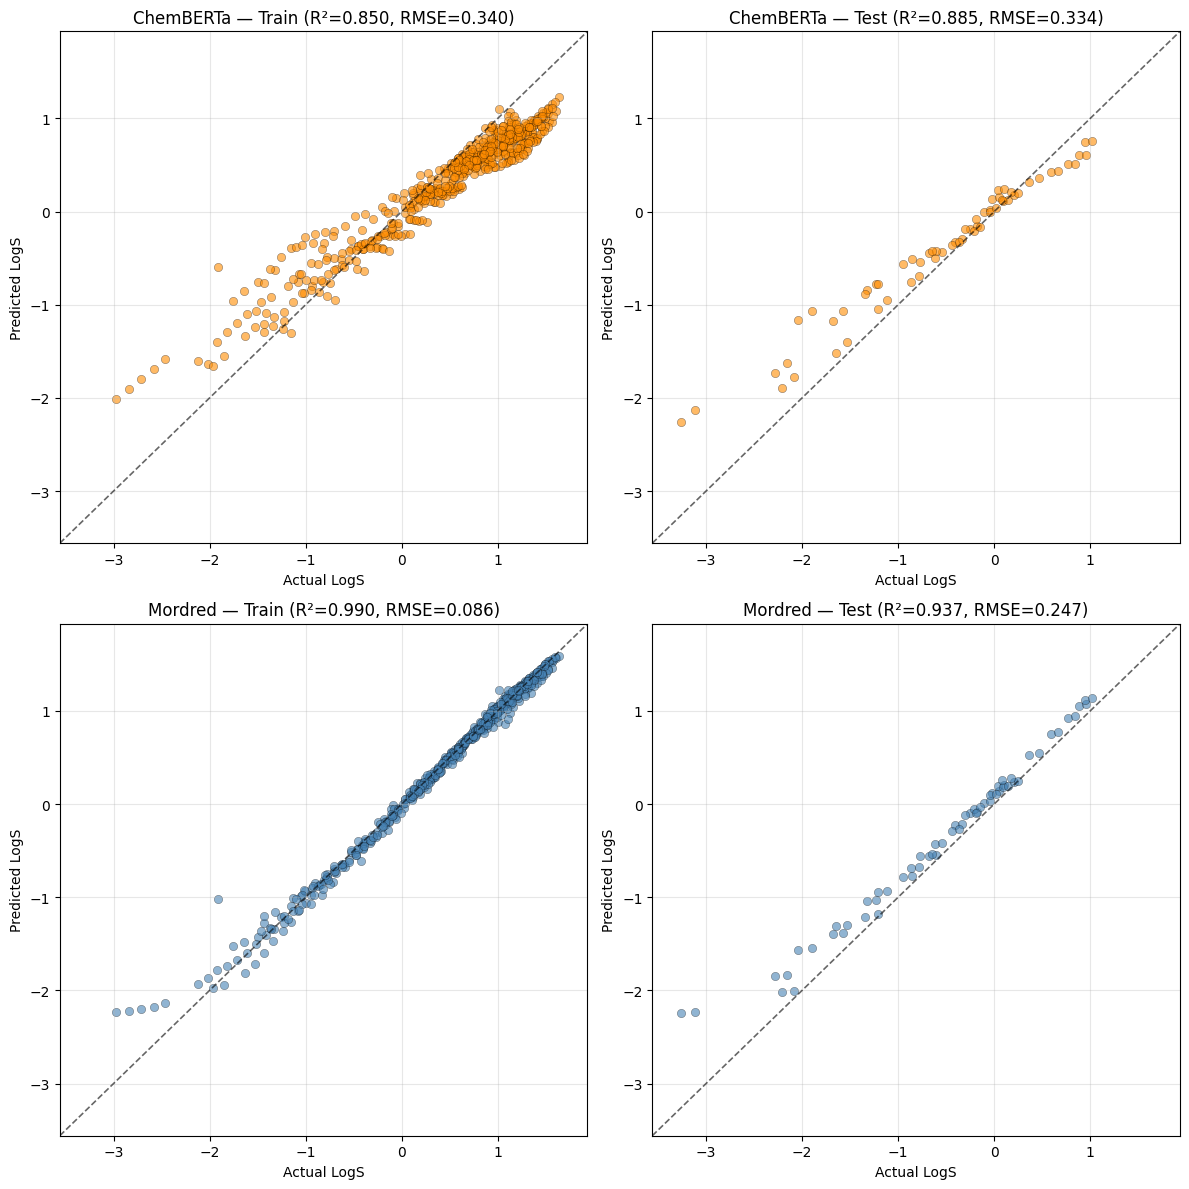

In [14]:
# ============================================================================
# min TEMPERATURE-BASED SPLIT — holds out T = 278.15 K and 283.15 K
# ============================================================================
HOLDOUT_TEMPS = [278.15, 283.15]
T = df['Temperature (K)'].values.reshape(-1, 1)
mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Temperature split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ---- MORDRED: min-temp split ----
scaler_fp_temp = StandardScaler().fit(X_fp[idx_temp_train])
scaler_comp_temp = StandardScaler().fit(x1[idx_temp_train])
scaler_temp_temp = StandardScaler().fit(T[idx_temp_train])

X_fp_train_temp = scaler_fp_temp.transform(X_fp[idx_temp_train])
X_fp_val_temp   = scaler_fp_temp.transform(X_fp[idx_temp_val])
X_fp_test_temp  = scaler_fp_temp.transform(X_fp[idx_temp_test])

x1_train_temp = scaler_comp_temp.transform(x1[idx_temp_train])
x1_val_temp   = scaler_comp_temp.transform(x1[idx_temp_val])
x1_test_temp  = scaler_comp_temp.transform(x1[idx_temp_test])

T_train_temp = scaler_temp_temp.transform(T[idx_temp_train])
T_val_temp   = scaler_temp_temp.transform(T[idx_temp_val])
T_test_temp  = scaler_temp_temp.transform(T[idx_temp_test])

Y_train_temp, Y_val_temp, Y_test_temp = Y[idx_temp_train], Y[idx_temp_val], Y[idx_temp_test]

print(f"[Temp split/Mordred] Train: {len(X_fp_train_temp)} | Val: {len(X_fp_val_temp)} | Test: {len(X_fp_test_temp)}")

X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t, Y_train_temp_t = map(
    to_t, [X_fp_train_temp, x1_train_temp, T_train_temp, Y_train_temp])
X_fp_val_temp_t, x1_val_temp_t, T_val_temp_t, Y_val_temp_t = map(
    to_t, [X_fp_val_temp, x1_val_temp, T_val_temp, Y_val_temp])
X_fp_test_temp_t, x1_test_temp_t, T_test_temp_t, Y_test_temp_t = map(
    to_t, [X_fp_test_temp, x1_test_temp, T_test_temp, Y_test_temp])

train_ds_temp = TensorDataset(X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t, Y_train_temp_t)
val_ds_temp   = TensorDataset(X_fp_val_temp_t,   x1_val_temp_t,   T_val_temp_t,   Y_val_temp_t)
test_ds_temp  = TensorDataset(X_fp_test_temp_t,  x1_test_temp_t,  T_test_temp_t,  Y_test_temp_t)

train_loader_temp = DataLoader(train_ds_temp, batch_size=32, shuffle=True)
val_loader_temp   = DataLoader(val_ds_temp,   batch_size=len(val_ds_temp),  shuffle=False)
test_loader_temp  = DataLoader(test_ds_temp,  batch_size=len(test_ds_temp), shuffle=False)

mordred_model_temp = SolubilityPureNNModel(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    n_temp_features=1, temp_emb_hidden_layers=[16, 16], temp_emb_dropout=0.1, temp_emb_actfunc='Tanh', temp_emb_size=16,
    out_hidden_layers=[32], out_dropout=0.1, out_actfunc='Tanh',
)
print(f"[Temp split/Mordred] Total trainable parameters: {mordred_model_temp.count_parameters()}")

optimizer_temp = torch.optim.Adam(mordred_model_temp.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss_temp, patience_counter_temp, best_weights_temp = float('inf'), 0, None
train_losses_temp, val_losses_temp = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model_temp.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader_temp:
        optimizer_temp.zero_grad()
        Y_pred = mordred_model_temp(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer_temp.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds_temp)

    mordred_model_temp.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader_temp:
            epoch_val_loss = criterion(mordred_model_temp(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses_temp.append(epoch_train_loss)
    val_losses_temp.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_temp:
        best_val_loss_temp = epoch_val_loss
        best_weights_temp = {k: v.clone() for k, v in mordred_model_temp.state_dict().items()}
        patience_counter_temp = 0
    else:
        patience_counter_temp += 1
        if patience_counter_temp >= PATIENCE:
            print(f"[Temp split/Mordred] Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"[Temp split/Mordred] Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model_temp.load_state_dict(best_weights_temp)
print(f"\n[Temp split/Mordred] Best val loss: {best_val_loss_temp:.4f}")

mordred_model_temp.eval()
with torch.no_grad():
    Y_pred_train_mordred_temp = mordred_model_temp(X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t).numpy().flatten()
    Y_pred_test_mordred_temp  = mordred_model_temp(X_fp_test_temp_t,  x1_test_temp_t,  T_test_temp_t).numpy().flatten()

Y_train_np_temp = Y_train_temp_t.numpy().flatten()
Y_test_np_temp  = Y_test_temp_t.numpy().flatten()

r2_train_m_temp, rmse_train_m_temp, mae_train_m_temp = get_metrics(Y_train_np_temp, Y_pred_train_mordred_temp)
r2_test_m_temp,  rmse_test_m_temp,  mae_test_m_temp  = get_metrics(Y_test_np_temp,  Y_pred_test_mordred_temp)

print(f"[Temp split/Mordred] Train | R²={r2_train_m_temp:.4f} RMSE={rmse_train_m_temp:.4f} MAE={mae_train_m_temp:.4f}")
print(f"[Temp split/Mordred] Test  | R²={r2_test_m_temp:.4f} RMSE={rmse_test_m_temp:.4f} MAE={mae_test_m_temp:.4f}")

# ---- CHEMBERTA: min-temp split ----
train_df_temp_chem = df.loc[idx_temp_train]
val_df_temp_chem   = df.loc[idx_temp_val]
test_df_temp_chem  = df.loc[idx_temp_test]

scaler_temp_chem_temp = StandardScaler().fit(train_df_temp_chem['Temperature (K)'].values.reshape(-1, 1))
chem_train_dataset_temp = SolubilityDataset(train_df_temp_chem, temp_scaler=scaler_temp_chem_temp)
chem_val_dataset_temp   = SolubilityDataset(val_df_temp_chem,   temp_scaler=scaler_temp_chem_temp)
chem_test_dataset_temp  = SolubilityDataset(test_df_temp_chem,  temp_scaler=scaler_temp_chem_temp)

chem_train_loader_temp = DataLoader(chem_train_dataset_temp, batch_size=32, shuffle=True, collate_fn=collate_fn)
chem_val_loader_temp   = DataLoader(chem_val_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_temp  = DataLoader(chem_test_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"[Temp split/ChemBERTa] Train: {len(chem_train_dataset_temp)} | Val: {len(chem_val_dataset_temp)} | Test: {len(chem_test_dataset_temp)}")

chemberta_model_temp = FineTunedChemBERTa(
    model_name="seyonec/ChemBERTa-zinc-base-v1",
    mix_emb_hidden_layers=[512, 256], mix_emb_dropout=0.3, mix_emb_actfunc='ReLU', mix_emb_size=128,
    temp_emb_hidden_layers=[16, 16], temp_emb_dropout=0.1, temp_emb_actfunc='ReLU', temp_emb_size=16,
    out_hidden_layers=[64, 32], out_dropout=0.2, out_actfunc='ReLU'
).to(DEVICE)
print(f"[Temp split/ChemBERTa] Total trainable parameters: {chemberta_model_temp.count_parameters():,}")

print("\n[Temp split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)")
chemberta_model_temp.freeze_chemberta()
train_losses_1_temp, val_losses_1_temp, r2_scores_1_temp, best_val_loss_c_temp, best_weights_c_temp = train_model(
    chemberta_model_temp, chem_train_loader_temp, chem_val_loader_temp,
    epochs=50, lr=0.001, device=DEVICE, stage_name="[Temp split] Stage 1"
)

print("\n[Temp split/ChemBERTa] STAGE 2: Fine-tuning (unfrozen)")
chemberta_model_temp.unfreeze_chemberta(unfreeze_layers=4)
train_losses_2_temp, val_losses_2_temp, r2_scores_2_temp, best_val_loss_c_temp, best_weights_c_temp = train_model(
    chemberta_model_temp, chem_train_loader_temp, chem_val_loader_temp,
    epochs=30, lr=0.0001, device=DEVICE, stage_name="[Temp split] Stage 2",
    best_val_loss=best_val_loss_c_temp, best_weights=best_weights_c_temp
)

chemberta_model_temp.load_state_dict(best_weights_c_temp)
print(f"\n[Temp split/ChemBERTa] Loaded best checkpoint (val loss = {best_val_loss_c_temp:.4f})")

chemberta_model_temp.eval()
test_preds_c_temp, test_targets_c_temp = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp(smiles1, smiles2, comp1, T_batch)
        test_preds_c_temp.extend(predictions.squeeze().cpu().numpy())
        test_targets_c_temp.extend(y.numpy())

test_preds_c_temp, test_targets_c_temp = np.array(test_preds_c_temp), np.array(test_targets_c_temp)
r2_c_temp, rmse_c_temp, mae_c_temp = get_metrics(test_targets_c_temp, test_preds_c_temp)
print(f"[Temp split/ChemBERTa] Test | R²={r2_c_temp:.4f} RMSE={rmse_c_temp:.4f} MAE={mae_c_temp:.4f}")

train_preds_c_temp, train_targets_c_temp = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp(smiles1, smiles2, comp1, T_batch)
        train_preds_c_temp.extend(predictions.squeeze().cpu().numpy())
        train_targets_c_temp.extend(y.numpy())

train_preds_c_temp, train_targets_c_temp = np.array(train_preds_c_temp), np.array(train_targets_c_temp)
r2_train_c_temp, rmse_train_c_temp, mae_train_c_temp = get_metrics(train_targets_c_temp, train_preds_c_temp)
print(f"[Temp split/ChemBERTa] Train | R²={r2_train_c_temp:.4f} RMSE={rmse_train_c_temp:.4f} MAE={mae_train_c_temp:.4f}")

# ---- 2x2 comparison: min-temp split ----
print("\n" + "="*60)
print("COMPARISON — TEMPERATURE-BASED SPLIT (278.15K & 283.15K held out)")
print("="*60)
print(f"{'Model':<12}{'Set':<8}{'R²':>10}{'RMSE':>10}{'MAE':>10}")
print(f"{'ChemBERTa':<12}{'Train':<8}{r2_train_c_temp:>10.4f}{rmse_train_c_temp:>10.4f}{mae_train_c_temp:>10.4f}")
print(f"{'ChemBERTa':<12}{'Test':<8}{r2_c_temp:>10.4f}{rmse_c_temp:>10.4f}{mae_c_temp:>10.4f}")
print(f"{'Mordred':<12}{'Train':<8}{r2_train_m_temp:>10.4f}{rmse_train_m_temp:>10.4f}{mae_train_m_temp:>10.4f}")
print(f"{'Mordred':<12}{'Test':<8}{r2_test_m_temp:>10.4f}{rmse_test_m_temp:>10.4f}{mae_test_m_temp:>10.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

all_vals_temp = np.concatenate([
    train_targets_c_temp, train_preds_c_temp, test_targets_c_temp, test_preds_c_temp,
    Y_train_np_temp, Y_pred_train_mordred_temp, Y_test_np_temp, Y_pred_test_mordred_temp
])
lims_temp = [all_vals_temp.min() - 0.3, all_vals_temp.max() + 0.3]

plot_specs_temp = [
    (0, 0, train_targets_c_temp, train_preds_c_temp, 'darkorange', 'ChemBERTa', 'Train', r2_train_c_temp, rmse_train_c_temp),
    (0, 1, test_targets_c_temp,  test_preds_c_temp,  'darkorange', 'ChemBERTa', 'Test',  r2_c_temp,        rmse_c_temp),
    (1, 0, Y_train_np_temp,      Y_pred_train_mordred_temp, 'steelblue', 'Mordred', 'Train', r2_train_m_temp, rmse_train_m_temp),
    (1, 1, Y_test_np_temp,       Y_pred_test_mordred_temp,  'steelblue', 'Mordred', 'Test',  r2_test_m_temp,  rmse_test_m_temp),
]

for row, col, y_true, y_pred, color, model_name, set_name, r2, rmse in plot_specs_temp:
    ax = axes[row, col]
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.3)
    ax.plot(lims_temp, lims_temp, 'k--', lw=1.2, alpha=0.6)
    ax.set_xlim(lims_temp); ax.set_ylim(lims_temp)
    ax.set_xlabel('Actual LogS'); ax.set_ylabel('Predicted LogS')
    ax.set_title(f'{model_name} — {set_name} (R²={r2:.3f}, RMSE={rmse:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('mordred_vs_chemberta_comparison_2x2_temp_split_pureNN.png', dpi=150)
plt.show()

In [15]:
# ── Save Mordred Pure NN (min temp split) model + scalers ──────────────────
torch.save({
    'model_state_dict': mordred_model_temp.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'n_temp_features': 1, 'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'Tanh', 'temp_emb_size': 16,
        'out_hidden_layers': [32], 'out_dropout': 0.1, 'out_actfunc': 'Tanh',
    }
}, 'mordred_pure_nn_min_temp_split_model.pt')

with open('mordred_pure_nn_min_temp_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp_temp, 'scaler_comp': scaler_comp_temp, 'scaler_temp': scaler_temp_temp}, f)

print("Saved model to 'mordred_pure_nn_min_temp_split_model.pt' and scalers to 'mordred_pure_nn_min_temp_split_scalers.pkl'")

# ── Save ChemBERTa Pure NN (min temp split) model + scaler ──────────────────
torch.save({
    'model_state_dict': chemberta_model_temp.state_dict(),
    'model_config': {
        'model_name': "seyonec/ChemBERTa-zinc-base-v1",
        'mix_emb_hidden_layers': [512, 256], 'mix_emb_dropout': 0.3, 'mix_emb_actfunc': 'ReLU', 'mix_emb_size': 128,
        'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'ReLU', 'temp_emb_size': 16,
        'out_hidden_layers': [64, 32], 'out_dropout': 0.2, 'out_actfunc': 'ReLU',
    }
}, 'chemberta_pure_nn_min_temp_split_model.pt')

with open('chemberta_pure_nn_min_temp_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_temp': scaler_temp_chem_temp}, f)

print("Saved model to 'chemberta_pure_nn_min_temp_split_model.pt' and scalers to 'chemberta_pure_nn_min_temp_split_scalers.pkl'")

Saved model to 'mordred_pure_nn_min_temp_split_model.pt' and scalers to 'mordred_pure_nn_min_temp_split_scalers.pkl'
Saved model to 'chemberta_pure_nn_min_temp_split_model.pt' and scalers to 'chemberta_pure_nn_min_temp_split_scalers.pkl'


In [16]:
# ============================================================================
# Load models and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load Mordred Pure NN (min temp split) model ────────────────────────────
checkpoint_mordred_temp = torch.load('mordred_pure_nn_min_temp_split_model.pt')

mordred_pure_nn_min_temp_loaded = SolubilityPureNNModel(**checkpoint_mordred_temp['model_config'])
mordred_pure_nn_min_temp_loaded.load_state_dict(checkpoint_mordred_temp['model_state_dict'])
mordred_pure_nn_min_temp_loaded.eval()

with open('mordred_pure_nn_min_temp_split_scalers.pkl', 'rb') as f:
    scalers_mordred_temp = pickle.load(f)
scaler_fp_min_temp_loaded = scalers_mordred_temp['scaler_fp']
scaler_comp_min_temp_loaded = scalers_mordred_temp['scaler_comp']
scaler_temp_min_temp_loaded = scalers_mordred_temp['scaler_temp']

print("Loaded mordred_pure_nn_min_temp_split_model and scalers — ready for inference/plotting, no training needed.")

# ── Load ChemBERTa Pure NN (min temp split) model ──────────────────────────
checkpoint_chemberta_temp = torch.load('chemberta_pure_nn_min_temp_split_model.pt', map_location=DEVICE)

chemberta_pure_nn_min_temp_loaded = FineTunedChemBERTa(**checkpoint_chemberta_temp['model_config']).to(DEVICE)
chemberta_pure_nn_min_temp_loaded.load_state_dict(checkpoint_chemberta_temp['model_state_dict'])
chemberta_pure_nn_min_temp_loaded.eval()

with open('chemberta_pure_nn_min_temp_split_scalers.pkl', 'rb') as f:
    scalers_chem_temp = pickle.load(f)
scaler_temp_chem_min_temp_loaded = scalers_chem_temp['scaler_temp']

print("Loaded chemberta_pure_nn_min_temp_split_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_pure_nn_min_temp_split_model and scalers — ready for inference/plotting, no training needed.
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_pure_nn_min_temp_split_model and scalers — ready for inference/plotting, no training needed.


Loaded mordred_pure_nn_min_temp_split_model and scalers
Recreated temp split -> Train: 528 | Val: 94 | Test: 62
Test temperatures: [278.15, 283.15]


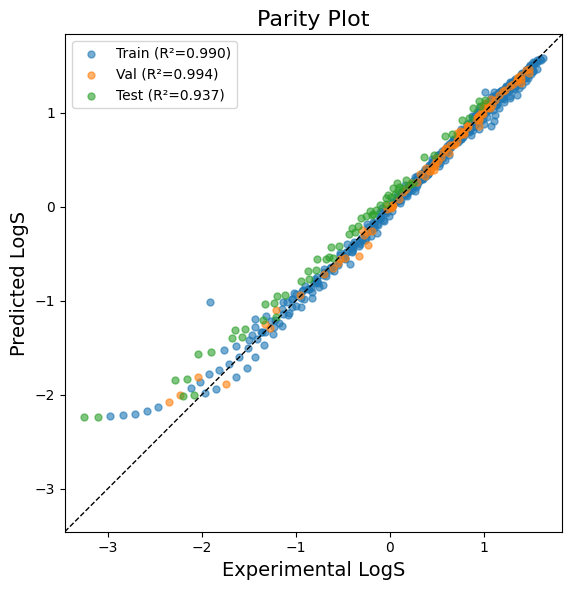

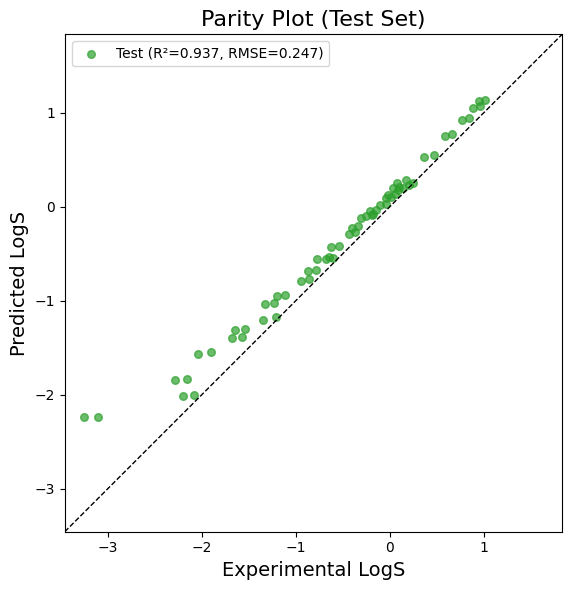


[Mordred Pure NN - Min Temp] Train | R²=0.9905 RMSE=0.0858, MAE=0.0458
[Mordred Pure NN - Min Temp] Val   | R²=0.9938 RMSE=0.0659, MAE=0.0428
[Mordred Pure NN - Min Temp] Test  | R²=0.9371 RMSE=0.2469, MAE=0.1830


In [20]:
# ============================================================================
# Plotting for Mordred Pure NN — Min Temperature Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split

# ── Load Mordred Pure NN (min temp split) model and scalers ──────────────
checkpoint_mordred_temp = torch.load('mordred_pure_nn_min_temp_split_model.pt')

mordred_pure_nn_min_temp_loaded = SolubilityPureNNModel(**checkpoint_mordred_temp['model_config'])
mordred_pure_nn_min_temp_loaded.load_state_dict(checkpoint_mordred_temp['model_state_dict'])
mordred_pure_nn_min_temp_loaded.eval()

with open('mordred_pure_nn_min_temp_split_scalers.pkl', 'rb') as f:
    scalers_mordred_temp = pickle.load(f)
scaler_fp_min_temp_loaded = scalers_mordred_temp['scaler_fp']
scaler_comp_min_temp_loaded = scalers_mordred_temp['scaler_comp']
scaler_temp_min_temp_loaded = scalers_mordred_temp['scaler_temp']

print("Loaded mordred_pure_nn_min_temp_split_model and scalers")

# ── Recreate the temperature split indices ──────────────────────────────────
HOLDOUT_TEMPS = [278.15, 283.15]  # Min temps held out

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Recreated temp split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ── Rebuild full arrays from dataframe ──────────────────────────────────────
T_full = df['Temperature (K)'].values.reshape(-1, 1)
Y_full = df['LogS'].values.reshape(-1, 1)

# ── Scale features using the LOADED scalers ─────────────────────────────────
X_fp_scaled = scaler_fp_min_temp_loaded.transform(X_fp)
x1_scaled = scaler_comp_min_temp_loaded.transform(x1)
T_scaled = scaler_temp_min_temp_loaded.transform(T_full)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

# ── Create tensors for Mordred Pure NN ─────────────────────────────────────
X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(
    to_t, [X_fp_scaled[idx_temp_train], x1_scaled[idx_temp_train], T_scaled[idx_temp_train], Y_full[idx_temp_train]]
)
X_fp_val_t, x1_val_t, T_val_t, Y_val_t = map(
    to_t, [X_fp_scaled[idx_temp_val], x1_scaled[idx_temp_val], T_scaled[idx_temp_val], Y_full[idx_temp_val]]
)
X_fp_test_t, x1_test_t, T_test_t, Y_test_t = map(
    to_t, [X_fp_scaled[idx_temp_test], x1_scaled[idx_temp_test], T_scaled[idx_temp_test], Y_full[idx_temp_test]]
)

# ── Get Mordred Pure NN predictions ────────────────────────────────────────
mordred_pure_nn_min_temp_loaded.eval()
with torch.no_grad():
    Y_pred_train = mordred_pure_nn_min_temp_loaded(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val   = mordred_pure_nn_min_temp_loaded(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test  = mordred_pure_nn_min_temp_loaded(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np = Y_train_t.numpy().flatten()
Y_val_np   = Y_val_t.numpy().flatten()
Y_test_np  = Y_test_t.numpy().flatten()

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(Y_train_np, Y_pred_train)
r2_val,   rmse_val   = get_metrics(Y_val_np,   Y_pred_val)
r2_test,  rmse_test  = get_metrics(Y_test_np,  Y_pred_test)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([Y_train_np, Y_val_np, Y_test_np])
all_pred = np.concatenate([Y_pred_train, Y_pred_val, Y_pred_test])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_train_np, Y_pred_train, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(Y_val_np,   Y_pred_val,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(Y_test_np,  Y_pred_test,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_test_np, Y_pred_test, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[Mordred Pure NN - Min Temp] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(Y_train_np - Y_pred_train)):.4f}")
print(f"[Mordred Pure NN - Min Temp] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(Y_val_np - Y_pred_val)):.4f}")
print(f"[Mordred Pure NN - Min Temp] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(Y_test_np - Y_pred_test)):.4f}")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_pure_nn_min_temp_split_model and scalers
Recreated temp split -> Train: 528 | Val: 94 | Test: 62
Test temperatures: [278.15, 283.15]
Dataset size: 528 samples
Dataset size: 94 samples
Dataset size: 62 samples


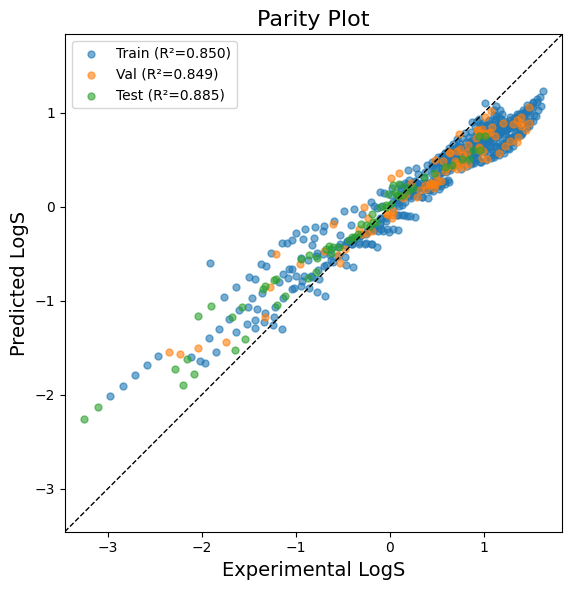

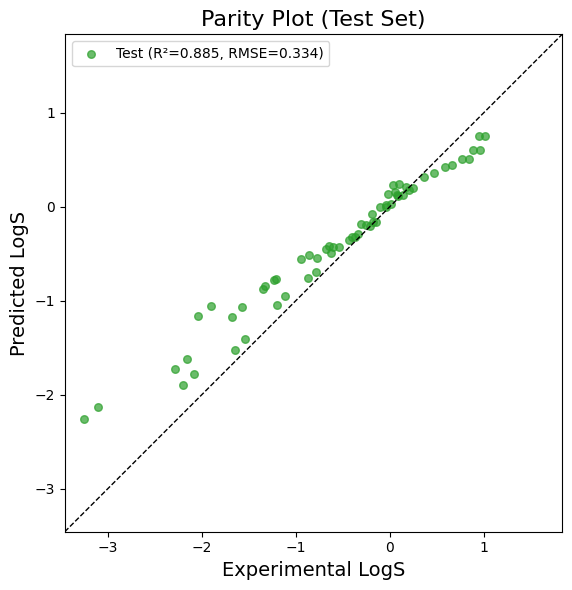


[ChemBERTa Pure NN - Min Temp] Train | R²=0.8498 RMSE=0.3403, MAE=0.2371
[ChemBERTa Pure NN - Min Temp] Val   | R²=0.8489 RMSE=0.3243, MAE=0.2656
[ChemBERTa Pure NN - Min Temp] Test  | R²=0.8848 RMSE=0.3343, MAE=0.2371


In [21]:
# ============================================================================
# Plotting for ChemBERTa Pure NN — Min Temperature Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

# ── Load ChemBERTa Pure NN (min temp split) model and scaler ──────────────
checkpoint_chemberta_temp = torch.load('chemberta_pure_nn_min_temp_split_model.pt', map_location=DEVICE)

chemberta_pure_nn_min_temp_loaded = FineTunedChemBERTa(**checkpoint_chemberta_temp['model_config']).to(DEVICE)
chemberta_pure_nn_min_temp_loaded.load_state_dict(checkpoint_chemberta_temp['model_state_dict'])
chemberta_pure_nn_min_temp_loaded.eval()

with open('chemberta_pure_nn_min_temp_split_scalers.pkl', 'rb') as f:
    scalers_chem_temp = pickle.load(f)
scaler_temp_chem_min_temp_loaded = scalers_chem_temp['scaler_temp']

print("Loaded chemberta_pure_nn_min_temp_split_model and scalers")

# ── Recreate the temperature split indices ──────────────────────────────────
HOLDOUT_TEMPS = [278.15, 283.15]  # Min temps held out

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Recreated temp split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ── Recreate datasets for ChemBERTa ──────────────────────────────────────────
train_df_temp_chem = df.loc[idx_temp_train]
val_df_temp_chem   = df.loc[idx_temp_val]
test_df_temp_chem  = df.loc[idx_temp_test]

# Use the loaded ChemBERTa temperature scaler
chem_train_dataset_temp = SolubilityDataset(train_df_temp_chem, temp_scaler=scaler_temp_chem_min_temp_loaded)
chem_val_dataset_temp   = SolubilityDataset(val_df_temp_chem,   temp_scaler=scaler_temp_chem_min_temp_loaded)
chem_test_dataset_temp  = SolubilityDataset(test_df_temp_chem,  temp_scaler=scaler_temp_chem_min_temp_loaded)

chem_train_loader_temp = DataLoader(chem_train_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_val_loader_temp   = DataLoader(chem_val_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_temp  = DataLoader(chem_test_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)

# ── Get ChemBERTa Pure NN predictions ──────────────────────────────────────
chemberta_pure_nn_min_temp_loaded.eval()

# Train predictions
train_preds, train_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_pure_nn_min_temp_loaded(smiles1, smiles2, comp1, T_batch)
        train_preds.extend(predictions.squeeze().cpu().numpy())
        train_targets.extend(y.numpy())

# Val predictions
val_preds, val_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_val_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_pure_nn_min_temp_loaded(smiles1, smiles2, comp1, T_batch)
        val_preds.extend(predictions.squeeze().cpu().numpy())
        val_targets.extend(y.numpy())

# Test predictions
test_preds, test_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_pure_nn_min_temp_loaded(smiles1, smiles2, comp1, T_batch)
        test_preds.extend(predictions.squeeze().cpu().numpy())
        test_targets.extend(y.numpy())

train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
val_preds = np.array(val_preds)
val_targets = np.array(val_targets)
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(train_targets, train_preds)
r2_val,   rmse_val   = get_metrics(val_targets,   val_preds)
r2_test,  rmse_test  = get_metrics(test_targets,  test_preds)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([train_targets, val_targets, test_targets])
all_pred = np.concatenate([train_preds, val_preds, test_preds])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(train_targets, train_preds, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(val_targets,   val_preds,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(test_targets,  test_preds,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_targets, test_preds, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[ChemBERTa Pure NN - Min Temp] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(test_targets - test_preds)):.4f}")
print(f"[ChemBERTa Pure NN - Min Temp] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(val_targets - val_preds)):.4f}")
print(f"[ChemBERTa Pure NN - Min Temp] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(test_targets - test_preds)):.4f}")

Temperature split -> Train: 537 | Val: 95 | Test: 52
Test temperatures: [328.15, 333.15]
[Temp split/Mordred] Train: 537 | Val: 95 | Test: 52
[Temp split/Mordred] Total trainable parameters: 874625
[Temp split/Mordred] Epoch   50 | Train: 0.1956 | Val: 0.0366
[Temp split/Mordred] Epoch  100 | Train: 0.1784 | Val: 0.0121
[Temp split/Mordred] Epoch  150 | Train: 0.1006 | Val: 0.0154
[Temp split/Mordred] Early stopping at epoch 172

[Temp split/Mordred] Best val loss: 0.0083
[Temp split/Mordred] Train | R²=0.9859 RMSE=0.1104 MAE=0.0687
[Temp split/Mordred] Test  | R²=0.9583 RMSE=0.1890 MAE=0.0889
Dataset size: 537 samples
Dataset size: 95 samples
Dataset size: 52 samples
[Temp split/ChemBERTa] Train: 537 | Val: 95 | Test: 52
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
[Temp split/ChemBERTa] Total trainable parameters: 45,068,409

[Temp split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)
Froze all ChemBERTa layers
[Temp split] Stage 1 Epoch 10/50: Train Loss: 0.4643, Val

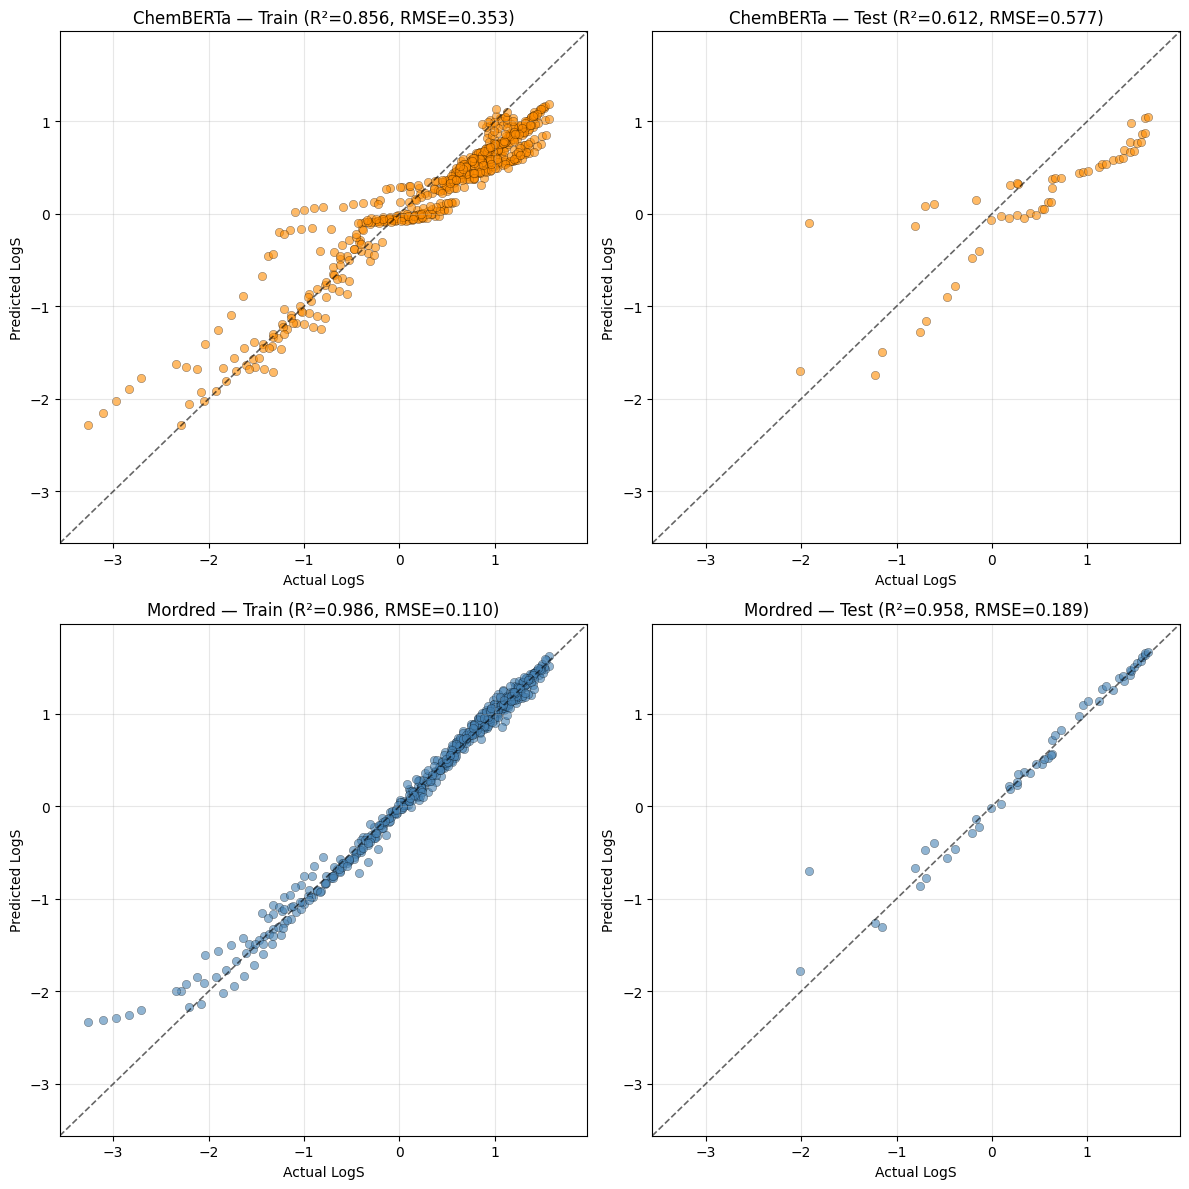

In [11]:
# ============================================================================
# max TEMPERATURE-BASED SPLIT — holds out T = 328.15 K and 333.15 K
# ============================================================================
HOLDOUT_TEMPS = [328.15, 333.15]

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Temperature split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ---- FIX: Extract temperature data properly ----
# Rename T to temperature_data to avoid conflict with .T transpose operation
temperature_data = df['Temperature (K)'].values.reshape(-1, 1)  # Shape: (n_samples, 1)

# ---- MORDRED: max-temp split ----
scaler_fp_temp = StandardScaler().fit(X_fp[idx_temp_train])
scaler_comp_temp = StandardScaler().fit(x1[idx_temp_train])
scaler_temp_temp = StandardScaler().fit(temperature_data[idx_temp_train])  # FIXED: Use temperature_data

X_fp_train_temp = scaler_fp_temp.transform(X_fp[idx_temp_train])
X_fp_val_temp   = scaler_fp_temp.transform(X_fp[idx_temp_val])
X_fp_test_temp  = scaler_fp_temp.transform(X_fp[idx_temp_test])

x1_train_temp = scaler_comp_temp.transform(x1[idx_temp_train])
x1_val_temp   = scaler_comp_temp.transform(x1[idx_temp_val])
x1_test_temp  = scaler_comp_temp.transform(x1[idx_temp_test])

T_train_temp = scaler_temp_temp.transform(temperature_data[idx_temp_train])  # FIXED
T_val_temp   = scaler_temp_temp.transform(temperature_data[idx_temp_val])    # FIXED
T_test_temp  = scaler_temp_temp.transform(temperature_data[idx_temp_test])   # FIXED

Y_train_temp, Y_val_temp, Y_test_temp = Y[idx_temp_train], Y[idx_temp_val], Y[idx_temp_test]

print(f"[Temp split/Mordred] Train: {len(X_fp_train_temp)} | Val: {len(X_fp_val_temp)} | Test: {len(X_fp_test_temp)}")

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t, Y_train_temp_t = map(
    to_t, [X_fp_train_temp, x1_train_temp, T_train_temp, Y_train_temp])
X_fp_val_temp_t, x1_val_temp_t, T_val_temp_t, Y_val_temp_t = map(
    to_t, [X_fp_val_temp, x1_val_temp, T_val_temp, Y_val_temp])
X_fp_test_temp_t, x1_test_temp_t, T_test_temp_t, Y_test_temp_t = map(
    to_t, [X_fp_test_temp, x1_test_temp, T_test_temp, Y_test_temp])

train_ds_temp = TensorDataset(X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t, Y_train_temp_t)
val_ds_temp   = TensorDataset(X_fp_val_temp_t,   x1_val_temp_t,   T_val_temp_t,   Y_val_temp_t)
test_ds_temp  = TensorDataset(X_fp_test_temp_t,  x1_test_temp_t,  T_test_temp_t,  Y_test_temp_t)

train_loader_temp = DataLoader(train_ds_temp, batch_size=32, shuffle=True)
val_loader_temp   = DataLoader(val_ds_temp,   batch_size=len(val_ds_temp),  shuffle=False)
test_loader_temp  = DataLoader(test_ds_temp,  batch_size=len(test_ds_temp), shuffle=False)

mordred_model_temp = SolubilityPureNNModel(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    n_temp_features=1, temp_emb_hidden_layers=[16, 16], temp_emb_dropout=0.1, temp_emb_actfunc='Tanh', temp_emb_size=16,
    out_hidden_layers=[32], out_dropout=0.1, out_actfunc='Tanh',
)
print(f"[Temp split/Mordred] Total trainable parameters: {mordred_model_temp.count_parameters()}")

optimizer_temp = torch.optim.Adam(mordred_model_temp.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss_temp, patience_counter_temp, best_weights_temp = float('inf'), 0, None
train_losses_temp, val_losses_temp = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model_temp.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader_temp:
        optimizer_temp.zero_grad()
        Y_pred = mordred_model_temp(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer_temp.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds_temp)

    mordred_model_temp.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader_temp:
            epoch_val_loss = criterion(mordred_model_temp(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses_temp.append(epoch_train_loss)
    val_losses_temp.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_temp:
        best_val_loss_temp = epoch_val_loss
        best_weights_temp = {k: v.clone() for k, v in mordred_model_temp.state_dict().items()}
        patience_counter_temp = 0
    else:
        patience_counter_temp += 1
        if patience_counter_temp >= PATIENCE:
            print(f"[Temp split/Mordred] Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"[Temp split/Mordred] Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model_temp.load_state_dict(best_weights_temp)
print(f"\n[Temp split/Mordred] Best val loss: {best_val_loss_temp:.4f}")

mordred_model_temp.eval()
with torch.no_grad():
    Y_pred_train_mordred_temp = mordred_model_temp(X_fp_train_temp_t, x1_train_temp_t, T_train_temp_t).numpy().flatten()
    Y_pred_test_mordred_temp  = mordred_model_temp(X_fp_test_temp_t,  x1_test_temp_t,  T_test_temp_t).numpy().flatten()

Y_train_np_temp = Y_train_temp_t.numpy().flatten()
Y_test_np_temp  = Y_test_temp_t.numpy().flatten()

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    return r2, rmse, mae

r2_train_m_temp, rmse_train_m_temp, mae_train_m_temp = get_metrics(Y_train_np_temp, Y_pred_train_mordred_temp)
r2_test_m_temp,  rmse_test_m_temp,  mae_test_m_temp  = get_metrics(Y_test_np_temp,  Y_pred_test_mordred_temp)

print(f"[Temp split/Mordred] Train | R²={r2_train_m_temp:.4f} RMSE={rmse_train_m_temp:.4f} MAE={mae_train_m_temp:.4f}")
print(f"[Temp split/Mordred] Test  | R²={r2_test_m_temp:.4f} RMSE={rmse_test_m_temp:.4f} MAE={mae_test_m_temp:.4f}")

# ---- CHEMBERTA: max-temp split ----
train_df_temp_chem = df.loc[idx_temp_train]
val_df_temp_chem   = df.loc[idx_temp_val]
test_df_temp_chem  = df.loc[idx_temp_test]

# FIXED: Use the same temperature_data variable
scaler_temp_chem_temp = StandardScaler().fit(temperature_data[idx_temp_train])  # FIXED
chem_train_dataset_temp = SolubilityDataset(train_df_temp_chem, temp_scaler=scaler_temp_chem_temp)
chem_val_dataset_temp   = SolubilityDataset(val_df_temp_chem,   temp_scaler=scaler_temp_chem_temp)
chem_test_dataset_temp  = SolubilityDataset(test_df_temp_chem,  temp_scaler=scaler_temp_chem_temp)

chem_train_loader_temp = DataLoader(chem_train_dataset_temp, batch_size=32, shuffle=True, collate_fn=collate_fn)
chem_val_loader_temp   = DataLoader(chem_val_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_temp  = DataLoader(chem_test_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"[Temp split/ChemBERTa] Train: {len(chem_train_dataset_temp)} | Val: {len(chem_val_dataset_temp)} | Test: {len(chem_test_dataset_temp)}")

chemberta_model_temp = FineTunedChemBERTa(
    model_name="seyonec/ChemBERTa-zinc-base-v1",
    mix_emb_hidden_layers=[512, 256], mix_emb_dropout=0.3, mix_emb_actfunc='ReLU', mix_emb_size=128,
    temp_emb_hidden_layers=[16, 16], temp_emb_dropout=0.1, temp_emb_actfunc='ReLU', temp_emb_size=16,
    out_hidden_layers=[64, 32], out_dropout=0.2, out_actfunc='ReLU'
).to(DEVICE)
print(f"[Temp split/ChemBERTa] Total trainable parameters: {chemberta_model_temp.count_parameters():,}")

print("\n[Temp split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)")
chemberta_model_temp.freeze_chemberta()
train_losses_1_temp, val_losses_1_temp, r2_scores_1_temp, best_val_loss_c_temp, best_weights_c_temp = train_model(
    chemberta_model_temp, chem_train_loader_temp, chem_val_loader_temp,
    epochs=50, lr=0.001, device=DEVICE, stage_name="[Temp split] Stage 1"
)

print("\n[Temp split/ChemBERTa] STAGE 2: Fine-tuning (unfrozen)")
chemberta_model_temp.unfreeze_chemberta(unfreeze_layers=4)
train_losses_2_temp, val_losses_2_temp, r2_scores_2_temp, best_val_loss_c_temp, best_weights_c_temp = train_model(
    chemberta_model_temp, chem_train_loader_temp, chem_val_loader_temp,
    epochs=30, lr=0.0001, device=DEVICE, stage_name="[Temp split] Stage 2",
    best_val_loss=best_val_loss_c_temp, best_weights=best_weights_c_temp
)

chemberta_model_temp.load_state_dict(best_weights_c_temp)
print(f"\n[Temp split/ChemBERTa] Loaded best checkpoint (val loss = {best_val_loss_c_temp:.4f})")

chemberta_model_temp.eval()
test_preds_c_temp, test_targets_c_temp = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp(smiles1, smiles2, comp1, T_batch)
        test_preds_c_temp.extend(predictions.squeeze().cpu().numpy())
        test_targets_c_temp.extend(y.numpy())

test_preds_c_temp, test_targets_c_temp = np.array(test_preds_c_temp), np.array(test_targets_c_temp)
r2_c_temp, rmse_c_temp, mae_c_temp = get_metrics(test_targets_c_temp, test_preds_c_temp)
print(f"[Temp split/ChemBERTa] Test | R²={r2_c_temp:.4f} RMSE={rmse_c_temp:.4f} MAE={mae_c_temp:.4f}")

train_preds_c_temp, train_targets_c_temp = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_temp(smiles1, smiles2, comp1, T_batch)
        train_preds_c_temp.extend(predictions.squeeze().cpu().numpy())
        train_targets_c_temp.extend(y.numpy())

train_preds_c_temp, train_targets_c_temp = np.array(train_preds_c_temp), np.array(train_targets_c_temp)
r2_train_c_temp, rmse_train_c_temp, mae_train_c_temp = get_metrics(train_targets_c_temp, train_preds_c_temp)
print(f"[Temp split/ChemBERTa] Train | R²={r2_train_c_temp:.4f} RMSE={rmse_train_c_temp:.4f} MAE={mae_train_c_temp:.4f}")

# ---- 2x2 comparison: max-temp split ----
print("\n" + "="*60)
print("COMPARISON — TEMPERATURE-BASED SPLIT (328.15K & 333.15K held out)")
print("="*60)
print(f"{'Model':<12}{'Set':<8}{'R²':>10}{'RMSE':>10}{'MAE':>10}")
print(f"{'ChemBERTa':<12}{'Train':<8}{r2_train_c_temp:>10.4f}{rmse_train_c_temp:>10.4f}{mae_train_c_temp:>10.4f}")
print(f"{'ChemBERTa':<12}{'Test':<8}{r2_c_temp:>10.4f}{rmse_c_temp:>10.4f}{mae_c_temp:>10.4f}")
print(f"{'Mordred':<12}{'Train':<8}{r2_train_m_temp:>10.4f}{rmse_train_m_temp:>10.4f}{mae_train_m_temp:>10.4f}")
print(f"{'Mordred':<12}{'Test':<8}{r2_test_m_temp:>10.4f}{rmse_test_m_temp:>10.4f}{mae_test_m_temp:>10.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

all_vals_temp = np.concatenate([
    train_targets_c_temp, train_preds_c_temp, test_targets_c_temp, test_preds_c_temp,
    Y_train_np_temp, Y_pred_train_mordred_temp, Y_test_np_temp, Y_pred_test_mordred_temp
])
lims_temp = [all_vals_temp.min() - 0.3, all_vals_temp.max() + 0.3]

plot_specs_temp = [
    (0, 0, train_targets_c_temp, train_preds_c_temp, 'darkorange', 'ChemBERTa', 'Train', r2_train_c_temp, rmse_train_c_temp),
    (0, 1, test_targets_c_temp,  test_preds_c_temp,  'darkorange', 'ChemBERTa', 'Test',  r2_c_temp,        rmse_c_temp),
    (1, 0, Y_train_np_temp,      Y_pred_train_mordred_temp, 'steelblue', 'Mordred', 'Train', r2_train_m_temp, rmse_train_m_temp),
    (1, 1, Y_test_np_temp,       Y_pred_test_mordred_temp,  'steelblue', 'Mordred', 'Test',  r2_test_m_temp,  rmse_test_m_temp),
]

for row, col, y_true, y_pred, color, model_name, set_name, r2, rmse in plot_specs_temp:
    ax = axes[row, col]
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.3)
    ax.plot(lims_temp, lims_temp, 'k--', lw=1.2, alpha=0.6)
    ax.set_xlim(lims_temp); ax.set_ylim(lims_temp)
    ax.set_xlabel('Actual LogS'); ax.set_ylabel('Predicted LogS')
    ax.set_title(f'{model_name} — {set_name} (R²={r2:.3f}, RMSE={rmse:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('mordred_vs_chemberta_comparison_2x2_temp_split_max_pureNN.png', dpi=150)
plt.show()

In [18]:
# ── Save Mordred Pure NN (max temp split) model + scalers ──────────────────
torch.save({
    'model_state_dict': mordred_model_temp.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'n_temp_features': 1, 'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'Tanh', 'temp_emb_size': 16,
        'out_hidden_layers': [32], 'out_dropout': 0.1, 'out_actfunc': 'Tanh',
    }
}, 'mordred_pure_nn_max_temp_split_model.pt')

with open('mordred_pure_nn_max_temp_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp_temp, 'scaler_comp': scaler_comp_temp, 'scaler_temp': scaler_temp_temp}, f)

print("Saved model to 'mordred_pure_nn_max_temp_split_model.pt' and scalers to 'mordred_pure_nn_max_temp_split_scalers.pkl'")
# ── Save ChemBERTa Pure NN (max temp split) model + scaler ──────────────────
torch.save({
    'model_state_dict': chemberta_model_temp.state_dict(),
    'model_config': {
        'model_name': "seyonec/ChemBERTa-zinc-base-v1",
        'mix_emb_hidden_layers': [512, 256], 'mix_emb_dropout': 0.3, 'mix_emb_actfunc': 'ReLU', 'mix_emb_size': 128,
        'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'ReLU', 'temp_emb_size': 16,
        'out_hidden_layers': [64, 32], 'out_dropout': 0.2, 'out_actfunc': 'ReLU',
    }
}, 'chemberta_pure_nn_max_temp_split_model.pt')

with open('chemberta_pure_nn_max_temp_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_temp': scaler_temp_chem_temp}, f)

print("Saved model to 'chemberta_pure_nn_max_temp_split_model.pt' and scalers to 'chemberta_pure_nn_max_temp_split_scalers.pkl'")

Saved model to 'mordred_pure_nn_max_temp_split_model.pt' and scalers to 'mordred_pure_nn_max_temp_split_scalers.pkl'
Saved model to 'chemberta_pure_nn_max_temp_split_model.pt' and scalers to 'chemberta_pure_nn_max_temp_split_scalers.pkl'


In [10]:
# ============================================================================
# Load models and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load Mordred Pure NN (max temp split) model ────────────────────────────
checkpoint_mordred_temp = torch.load('mordred_pure_nn_max_temp_split_model.pt')

mordred_pure_nn_max_temp_loaded = SolubilityPureNNModel(**checkpoint_mordred_temp['model_config'])
mordred_pure_nn_max_temp_loaded.load_state_dict(checkpoint_mordred_temp['model_state_dict'])
mordred_pure_nn_max_temp_loaded.eval()

with open('mordred_pure_nn_max_temp_split_scalers.pkl', 'rb') as f:
    scalers_mordred_temp = pickle.load(f)
scaler_fp_max_temp_loaded = scalers_mordred_temp['scaler_fp']
scaler_comp_max_temp_loaded = scalers_mordred_temp['scaler_comp']
scaler_temp_max_temp_loaded = scalers_mordred_temp['scaler_temp']

print("Loaded mordred_pure_nn_max_temp_split_model and scalers — ready for inference/plotting, no training needed.")

# ── Load ChemBERTa Pure NN (max temp split) model ──────────────────────────
checkpoint_chemberta_temp = torch.load('chemberta_pure_nn_max_temp_split_model.pt', map_location=DEVICE)

chemberta_pure_nn_max_temp_loaded = FineTunedChemBERTa(**checkpoint_chemberta_temp['model_config']).to(DEVICE)
chemberta_pure_nn_max_temp_loaded.load_state_dict(checkpoint_chemberta_temp['model_state_dict'])
chemberta_pure_nn_max_temp_loaded.eval()

with open('chemberta_pure_nn_max_temp_split_scalers.pkl', 'rb') as f:
    scalers_chem_temp = pickle.load(f)
scaler_temp_chem_max_temp_loaded = scalers_chem_temp['scaler_temp']

print("Loaded chemberta_pure_nn_max_temp_split_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_pure_nn_max_temp_split_model and scalers — ready for inference/plotting, no training needed.
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_pure_nn_max_temp_split_model and scalers — ready for inference/plotting, no training needed.


Loaded mordred_pure_nn_max_temp_split_model and scalers
Recreated temp split -> Train: 537 | Val: 95 | Test: 52
Test temperatures: [328.15, 333.15]


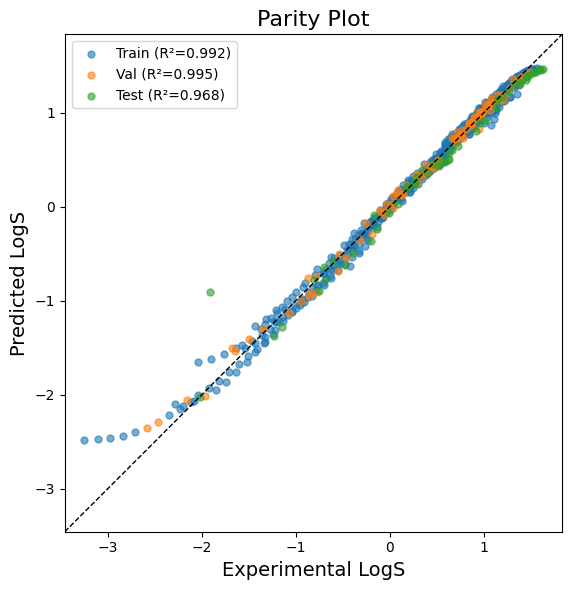

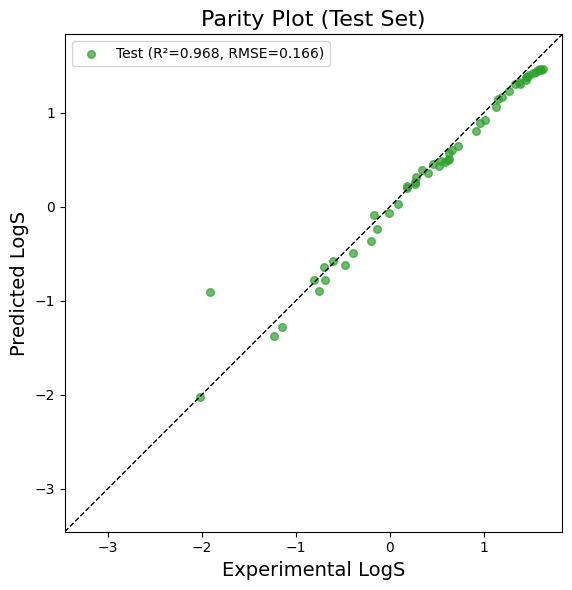


[Mordred Pure NN - Max Temp] Train | R²=0.9922 RMSE=0.0823 MAE=0.0526
[Mordred Pure NN - Max Temp] Val   | R²=0.9952 RMSE=0.0640 MAE=0.0503
[Mordred Pure NN - Max Temp] Test  | R²=0.9680 RMSE=0.1655 MAE=0.0951


In [17]:
# ============================================================================
# Plotting for Mordred Pure NN — Max Temperature Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split

# ── Load Mordred Pure NN (max temp split) model and scalers ──────────────
checkpoint_mordred_temp = torch.load('mordred_pure_nn_max_temp_split_model.pt')

mordred_pure_nn_max_temp_loaded = SolubilityPureNNModel(**checkpoint_mordred_temp['model_config'])
mordred_pure_nn_max_temp_loaded.load_state_dict(checkpoint_mordred_temp['model_state_dict'])
mordred_pure_nn_max_temp_loaded.eval()

with open('mordred_pure_nn_max_temp_split_scalers.pkl', 'rb') as f:
    scalers_mordred_temp = pickle.load(f)
scaler_fp_max_temp_loaded = scalers_mordred_temp['scaler_fp']
scaler_comp_max_temp_loaded = scalers_mordred_temp['scaler_comp']
scaler_temp_max_temp_loaded = scalers_mordred_temp['scaler_temp']

print("Loaded mordred_pure_nn_max_temp_split_model and scalers")

# ── Recreate the temperature split indices ──────────────────────────────────
HOLDOUT_TEMPS = [328.15, 333.15]  # Max temps held out

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Recreated temp split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ── Rebuild full arrays from dataframe ──────────────────────────────────────
T_full = df['Temperature (K)'].values.reshape(-1, 1)
Y_full = df['LogS'].values.reshape(-1, 1)

# ── Scale features using the LOADED scalers ─────────────────────────────────
X_fp_scaled = scaler_fp_max_temp_loaded.transform(X_fp)
x1_scaled = scaler_comp_max_temp_loaded.transform(x1)
T_scaled = scaler_temp_max_temp_loaded.transform(T_full)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

# ── Create tensors for Mordred Pure NN ─────────────────────────────────────
X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(
    to_t, [X_fp_scaled[idx_temp_train], x1_scaled[idx_temp_train], T_scaled[idx_temp_train], Y_full[idx_temp_train]]
)
X_fp_val_t, x1_val_t, T_val_t, Y_val_t = map(
    to_t, [X_fp_scaled[idx_temp_val], x1_scaled[idx_temp_val], T_scaled[idx_temp_val], Y_full[idx_temp_val]]
)
X_fp_test_t, x1_test_t, T_test_t, Y_test_t = map(
    to_t, [X_fp_scaled[idx_temp_test], x1_scaled[idx_temp_test], T_scaled[idx_temp_test], Y_full[idx_temp_test]]
)

# ── Get Mordred Pure NN predictions ────────────────────────────────────────
mordred_pure_nn_max_temp_loaded.eval()
with torch.no_grad():
    Y_pred_train = mordred_pure_nn_max_temp_loaded(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val   = mordred_pure_nn_max_temp_loaded(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test  = mordred_pure_nn_max_temp_loaded(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np = Y_train_t.numpy().flatten()
Y_val_np   = Y_val_t.numpy().flatten()
Y_test_np  = Y_test_t.numpy().flatten()

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(Y_train_np, Y_pred_train)
r2_val,   rmse_val   = get_metrics(Y_val_np,   Y_pred_val)
r2_test,  rmse_test  = get_metrics(Y_test_np,  Y_pred_test)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([Y_train_np, Y_val_np, Y_test_np])
all_pred = np.concatenate([Y_pred_train, Y_pred_val, Y_pred_test])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_train_np, Y_pred_train, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(Y_val_np,   Y_pred_val,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(Y_test_np,  Y_pred_test,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_test_np, Y_pred_test, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[Mordred Pure NN - Max Temp] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}", f"MAE={np.mean(np.abs(Y_train_np - Y_pred_train)):.4f}")
print(f"[Mordred Pure NN - Max Temp] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}", f"MAE={np.mean(np.abs(Y_val_np - Y_pred_val)):.4f}")
print(f"[Mordred Pure NN - Max Temp] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}", f"MAE={np.mean(np.abs(Y_test_np - Y_pred_test)):.4f}")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_pure_nn_max_temp_split_model and scalers
Recreated temp split -> Train: 537 | Val: 95 | Test: 52
Test temperatures: [328.15, 333.15]
Dataset size: 537 samples
Dataset size: 95 samples
Dataset size: 52 samples


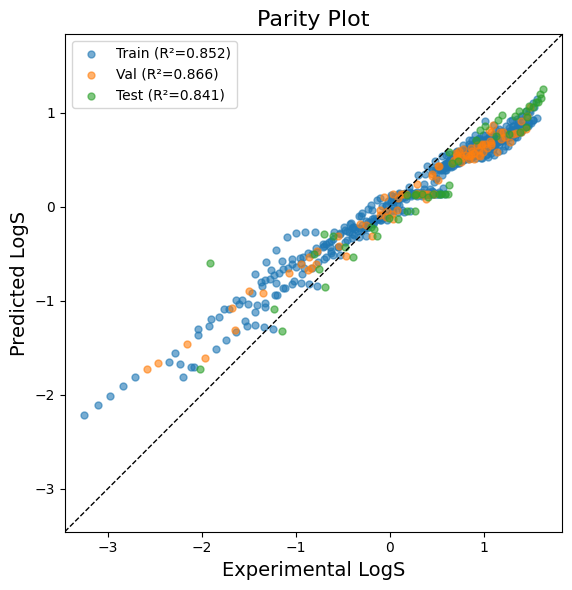

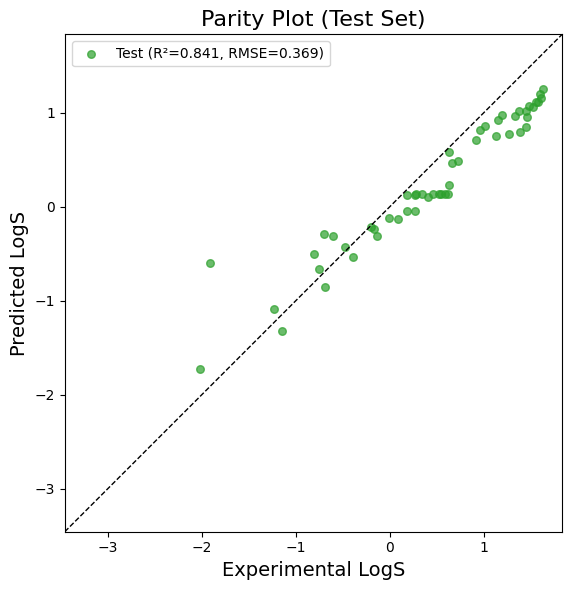


[ChemBERTa Pure NN - Max Temp] Train | R²=0.8522 RMSE=0.3575, MAE=0.3050
[ChemBERTa Pure NN - Max Temp] Val   | R²=0.8658 RMSE=0.3371, MAE=0.2848
[ChemBERTa Pure NN - Max Temp] Test  | R²=0.8414 RMSE=0.3689, MAE=0.3064


In [18]:
# ============================================================================
# Plotting for ChemBERTa Pure NN — Max Temperature Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

# ── Load ChemBERTa Pure NN (max temp split) model and scaler ──────────────
checkpoint_chemberta_temp = torch.load('chemberta_pure_nn_max_temp_split_model.pt', map_location=DEVICE)

chemberta_pure_nn_max_temp_loaded = FineTunedChemBERTa(**checkpoint_chemberta_temp['model_config']).to(DEVICE)
chemberta_pure_nn_max_temp_loaded.load_state_dict(checkpoint_chemberta_temp['model_state_dict'])
chemberta_pure_nn_max_temp_loaded.eval()

with open('chemberta_pure_nn_max_temp_split_scalers.pkl', 'rb') as f:
    scalers_chem_temp = pickle.load(f)
scaler_temp_chem_max_temp_loaded = scalers_chem_temp['scaler_temp']

print("Loaded chemberta_pure_nn_max_temp_split_model and scalers")

# ── Recreate the temperature split indices ──────────────────────────────────
HOLDOUT_TEMPS = [328.15, 333.15]  # Max temps held out

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Recreated temp split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ── Recreate datasets for ChemBERTa ──────────────────────────────────────────
train_df_temp_chem = df.loc[idx_temp_train]
val_df_temp_chem   = df.loc[idx_temp_val]
test_df_temp_chem  = df.loc[idx_temp_test]

# Use the loaded ChemBERTa temperature scaler
chem_train_dataset_temp = SolubilityDataset(train_df_temp_chem, temp_scaler=scaler_temp_chem_max_temp_loaded)
chem_val_dataset_temp   = SolubilityDataset(val_df_temp_chem,   temp_scaler=scaler_temp_chem_max_temp_loaded)
chem_test_dataset_temp  = SolubilityDataset(test_df_temp_chem,  temp_scaler=scaler_temp_chem_max_temp_loaded)

chem_train_loader_temp = DataLoader(chem_train_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_val_loader_temp   = DataLoader(chem_val_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_temp  = DataLoader(chem_test_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)

# ── Get ChemBERTa Pure NN predictions ──────────────────────────────────────
chemberta_pure_nn_max_temp_loaded.eval()

# Train predictions
train_preds, train_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_pure_nn_max_temp_loaded(smiles1, smiles2, comp1, T_batch)
        train_preds.extend(predictions.squeeze().cpu().numpy())
        train_targets.extend(y.numpy())

# Val predictions
val_preds, val_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_val_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_pure_nn_max_temp_loaded(smiles1, smiles2, comp1, T_batch)
        val_preds.extend(predictions.squeeze().cpu().numpy())
        val_targets.extend(y.numpy())

# Test predictions
test_preds, test_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_pure_nn_max_temp_loaded(smiles1, smiles2, comp1, T_batch)
        test_preds.extend(predictions.squeeze().cpu().numpy())
        test_targets.extend(y.numpy())

train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
val_preds = np.array(val_preds)
val_targets = np.array(val_targets)
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(train_targets, train_preds)
r2_val,   rmse_val   = get_metrics(val_targets,   val_preds)
r2_test,  rmse_test  = get_metrics(test_targets,  test_preds)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([train_targets, val_targets, test_targets])
all_pred = np.concatenate([train_preds, val_preds, test_preds])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(train_targets, train_preds, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(val_targets,   val_preds,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(test_targets,  test_preds,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_targets, test_preds, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[ChemBERTa Pure NN - Max Temp] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(train_targets - train_preds)):.4f}")
print(f"[ChemBERTa Pure NN - Max Temp] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(val_targets - val_preds)):.4f}")
print(f"[ChemBERTa Pure NN - Max Temp] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(test_targets - test_preds)):.4f}")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_max_temp_split_model — ready for inference/plotting, no training needed.
Recreated temp split -> Train: 537 | Val: 95 | Test: 52
Test temperatures: [328.15, 333.15]
Dataset size: 684 samples


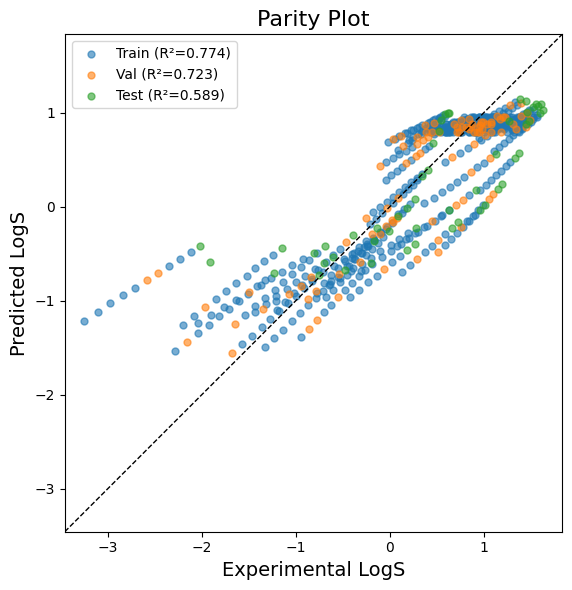

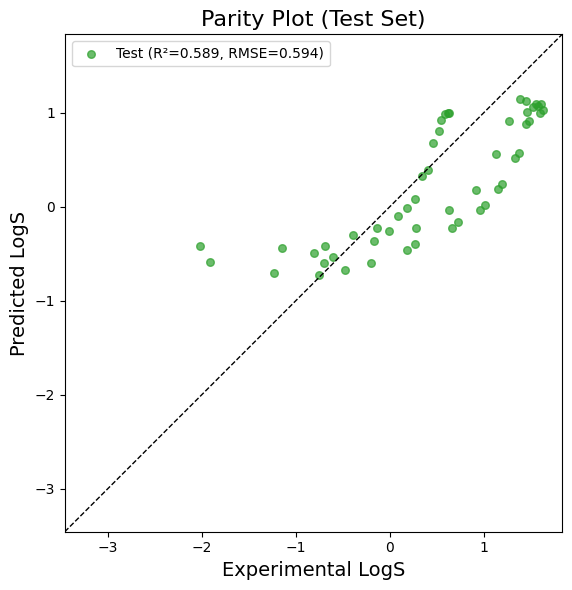


[ChemBERTa (Van't Hoff) - Max Temp] Train | R²=0.7736 RMSE=0.4425, MAE=0.3297
[ChemBERTa (Van't Hoff) - Max Temp] Val   | R²=0.7234 RMSE=0.4839, MAE=0.3576
[ChemBERTa (Van't Hoff) - Max Temp] Test  | R²=0.5887 RMSE=0.5939, MAE=0.4908


In [ ]:
# ============================================================================
# Plotting for ChemBERTa (Van't Hoff) — Max Temperature Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset

# ── Load ChemBERTa (Van't Hoff) max temp split model ──────────────────────
checkpoint_chemberta_max_temp = torch.load('chemberta_max_temp_split_model.pt', map_location=DEVICE)

chemberta_model_max_temp_loaded = FineTunedChemBERTa(**checkpoint_chemberta_max_temp['model_config']).to(DEVICE)
chemberta_model_max_temp_loaded.load_state_dict(checkpoint_chemberta_max_temp['model_state_dict'])
chemberta_model_max_temp_loaded.eval()

print("Loaded chemberta_max_temp_split_model — ready for inference/plotting, no training needed.")

# ── Recreate the temperature split indices ──────────────────────────────────
HOLDOUT_TEMPS = [328.15, 333.15]  # Max temps held out

mask_temp_test = df['Temperature (K)'].apply(
    lambda t: any(np.isclose(t, ht, atol=1e-6) for ht in HOLDOUT_TEMPS)
)
idx_temp_test = df.index[mask_temp_test].values
idx_temp_remain = df.index[~mask_temp_test].values
idx_temp_train, idx_temp_val = train_test_split(idx_temp_remain, test_size=0.15, random_state=42)

print(f"Recreated temp split -> Train: {len(idx_temp_train)} | Val: {len(idx_temp_val)} | Test: {len(idx_temp_test)}")
print(f"Test temperatures: {sorted(df.loc[idx_temp_test, 'Temperature (K)'].unique())}")

# ── Recreate datasets for ChemBERTa (Van't Hoff) ────────────────────────────
# Note: Van't Hoff ChemBERTa uses the dataset without temperature scaler
chemberta_dataset = SolubilityDataset(df)  # Original dataset without temp scaler

chem_train_dataset_temp = Subset(chemberta_dataset, idx_temp_train)
chem_val_dataset_temp   = Subset(chemberta_dataset, idx_temp_val)
chem_test_dataset_temp  = Subset(chemberta_dataset, idx_temp_test)

chem_train_loader_temp = DataLoader(chem_train_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_val_loader_temp   = DataLoader(chem_val_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_temp  = DataLoader(chem_test_dataset_temp, batch_size=32, shuffle=False, collate_fn=collate_fn)

# ── Get ChemBERTa predictions ──────────────────────────────────────────────
chemberta_model_max_temp_loaded.eval()

# Train predictions
train_preds, train_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_max_temp_loaded(smiles1, smiles2, comp1, T_batch)
        train_preds.extend(predictions.squeeze().cpu().numpy())
        train_targets.extend(y.numpy())

# Val predictions
val_preds, val_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_val_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_max_temp_loaded(smiles1, smiles2, comp1, T_batch)
        val_preds.extend(predictions.squeeze().cpu().numpy())
        val_targets.extend(y.numpy())

# Test predictions
test_preds, test_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_temp:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_max_temp_loaded(smiles1, smiles2, comp1, T_batch)
        test_preds.extend(predictions.squeeze().cpu().numpy())
        test_targets.extend(y.numpy())

train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
val_preds = np.array(val_preds)
val_targets = np.array(val_targets)
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(train_targets, train_preds)
r2_val,   rmse_val   = get_metrics(val_targets,   val_preds)
r2_test,  rmse_test  = get_metrics(test_targets,  test_preds)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([train_targets, val_targets, test_targets])
all_pred = np.concatenate([train_preds, val_preds, test_preds])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(train_targets, train_preds, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(val_targets,   val_preds,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(test_targets,  test_preds,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_targets, test_preds, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=14)
plt.ylabel('Predicted LogS', fontsize=14)
plt.title('Parity Plot (Test Set)', fontsize=16)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[ChemBERTa (Van't Hoff) - Max Temp] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(train_targets - train_preds)):.4f}")
print(f"[ChemBERTa (Van't Hoff) - Max Temp] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(val_targets - val_preds)):.4f}")
print(f"[ChemBERTa (Van't Hoff) - Max Temp] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(test_targets - test_preds)):.4f}")

In [2]:
import pandas as pd
from rdkit import Chem

df = pd.read_csv('Clozapine_dataset.csv')

def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else smiles
    except Exception:
        return smiles

# ── Canonicalize SMILES only to correctly GROUP pairs (e.g. A+B same as B+A) ──
# Names come directly from your dataset's own Solvent_1/Solvent_2 columns —
# no manually-written SMILES-to-name mapping involved.
df['_s1_canon'] = df['SMILES_1'].apply(canon)
df['_s2_canon'] = df['SMILES_2'].apply(canon)

# Build a canonical-SMILES -> name map straight from the dataset itself
name_from_canon = {}
for _, row in df.iterrows():
    name_from_canon.setdefault(row['_s1_canon'], row['Solvent_1'])
    name_from_canon.setdefault(row['_s2_canon'], row['Solvent_2'])

df['_pair'] = df.apply(lambda r: tuple(sorted([r['_s1_canon'], r['_s2_canon']])), axis=1)

pair_counts = df['_pair'].value_counts().reset_index()
pair_counts.columns = ['solvent_pair', 'count']

pair_counts['Solvent_A'] = pair_counts['solvent_pair'].apply(lambda p: name_from_canon.get(p[0], 'Unknown'))
pair_counts['Solvent_B'] = pair_counts['solvent_pair'].apply(lambda p: name_from_canon.get(p[1], 'Unknown'))
pair_counts = pair_counts[['Solvent_A', 'Solvent_B', 'count']]

print(f"Number of unique solvent-pair combinations: {len(pair_counts)}")
print(pair_counts.to_string(index=False))

df.drop(columns=['_s1_canon', '_s2_canon', '_pair'], inplace=True)

Number of unique solvent-pair combinations: 8
             Solvent_A          Solvent_B  count
            2-Propanol              Water    121
          Acetonitrile              Water    110
N-methyl-2-pyrrolidone              Water    110
    Dimethyl sulfoxide              Water     91
       Tetrahydrofuran            Toluene     63
               Toluene         Chloroform     63
               Toluene 1,2-Dichloroethane     63
               Acetone            Toluene     63


Rows found for Water + 2-Propanol pair: 121
Solvent-pair split -> Train: 478 | Val: 85 | Test: 121
[Solvent split/Mordred] Train: 478 | Val: 85 | Test: 121
[Solvent split/Mordred] Total trainable parameters: 874625
[Solvent split/Mordred] Epoch   50 | Train: 0.1730 | Val: 0.0220
[Solvent split/Mordred] Epoch  100 | Train: 0.1134 | Val: 0.0211
[Solvent split/Mordred] Epoch  150 | Train: 0.1304 | Val: 0.0103
[Solvent split/Mordred] Epoch  200 | Train: 0.1105 | Val: 0.0123
[Solvent split/Mordred] Epoch  250 | Train: 0.1621 | Val: 0.0065
[Solvent split/Mordred] Epoch  300 | Train: 0.1247 | Val: 0.0040
[Solvent split/Mordred] Epoch  350 | Train: 0.0866 | Val: 0.0043
[Solvent split/Mordred] Epoch  400 | Train: 0.1246 | Val: 0.0035
[Solvent split/Mordred] Early stopping at epoch 436

[Solvent split/Mordred] Best val loss: 0.0030
[Solvent split/Mordred] Train | R²=0.9923 RMSE=0.0722 MAE=0.0466
[Solvent split/Mordred] Test  | R²=0.5123 RMSE=0.6468 MAE=0.5811
Dataset size: 478 samples
Dataset si

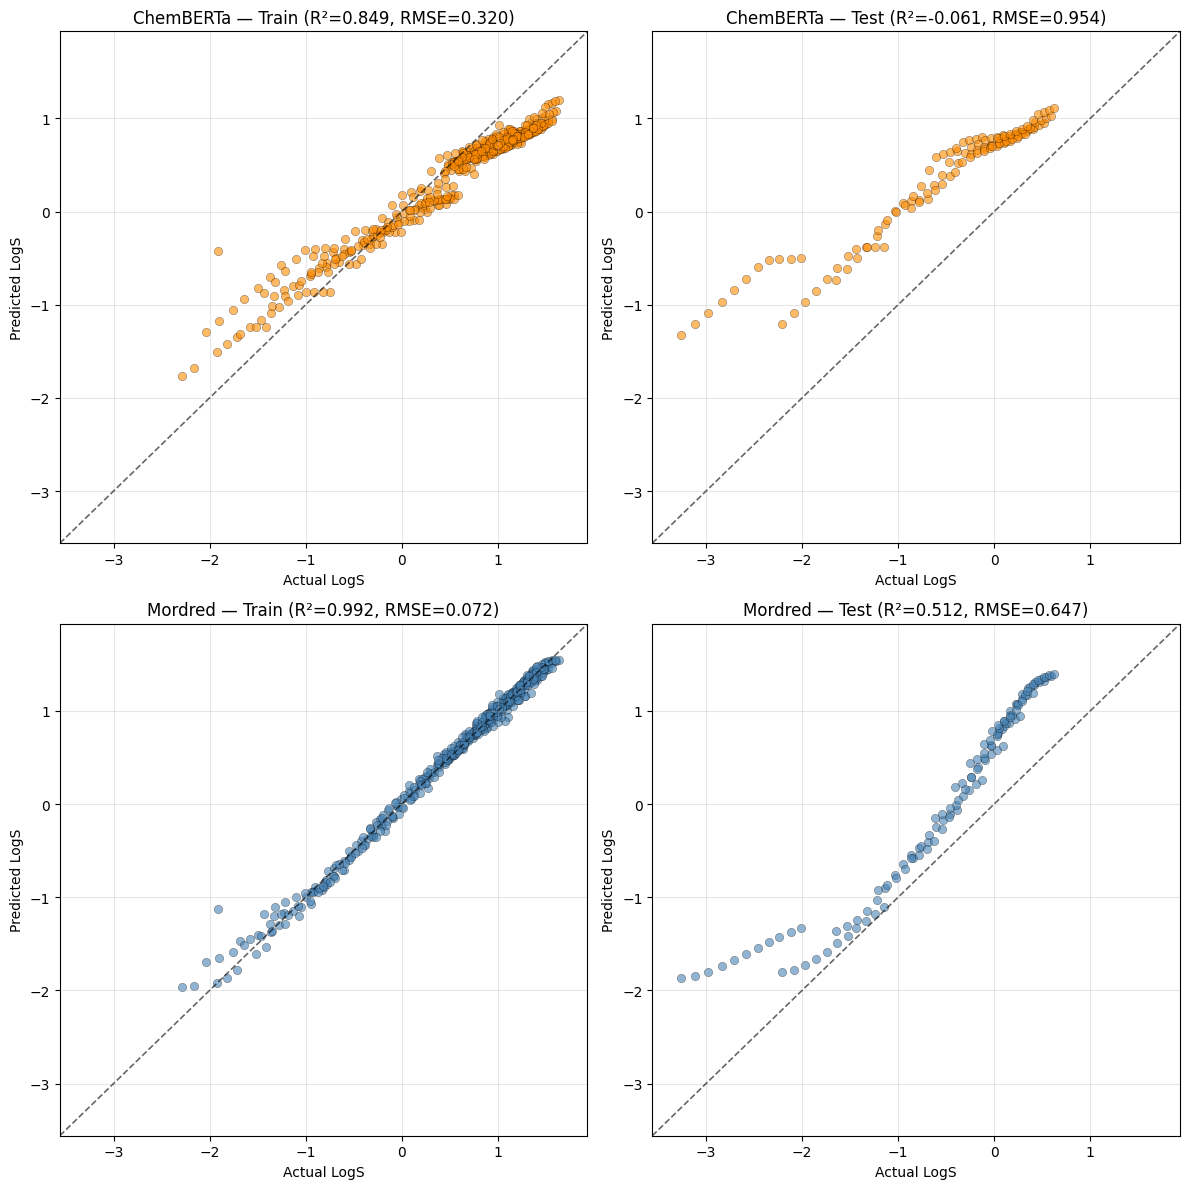

In [22]:
# ============================================================================
# SOLVENT-PAIR-BASED SPLIT — holds out Water + 2-Propanol
# ============================================================================
WATER_SMILES = "O"
ISOPROPANOL_SMILES = "CC(C)O"

def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None

water_canon = canon(WATER_SMILES)
ipa_canon = canon(ISOPROPANOL_SMILES)

df['_smiles1_canon'] = df['SMILES_1'].apply(canon)
df['_smiles2_canon'] = df['SMILES_2'].apply(canon)

mask_solv_test = (
    ((df['_smiles1_canon'] == water_canon) & (df['_smiles2_canon'] == ipa_canon)) |
    ((df['_smiles1_canon'] == ipa_canon) & (df['_smiles2_canon'] == water_canon))
)

idx_solv_test = df.index[mask_solv_test].values
idx_solv_remain = df.index[~mask_solv_test].values

print(f"Rows found for Water + 2-Propanol pair: {len(idx_solv_test)}")
if len(idx_solv_test) == 0:
    print("WARNING: no rows matched — check that this solvent pair actually exists in the dataset.")
    print(df[['SMILES_1', 'SMILES_2']].drop_duplicates().to_string())

idx_solv_train, idx_solv_val = train_test_split(idx_solv_remain, test_size=0.15, random_state=42)
print(f"Solvent-pair split -> Train: {len(idx_solv_train)} | Val: {len(idx_solv_val)} | Test: {len(idx_solv_test)}")

df.drop(columns=['_smiles1_canon', '_smiles2_canon'], inplace=True)

# ---- MORDRED: solvent-pair split ----
scaler_fp_solv = StandardScaler().fit(X_fp[idx_solv_train])
scaler_comp_solv = StandardScaler().fit(x1[idx_solv_train])
scaler_temp_solv = StandardScaler().fit(T[idx_solv_train])

X_fp_train_solv = scaler_fp_solv.transform(X_fp[idx_solv_train])
X_fp_val_solv   = scaler_fp_solv.transform(X_fp[idx_solv_val])
X_fp_test_solv  = scaler_fp_solv.transform(X_fp[idx_solv_test])

x1_train_solv = scaler_comp_solv.transform(x1[idx_solv_train])
x1_val_solv   = scaler_comp_solv.transform(x1[idx_solv_val])
x1_test_solv  = scaler_comp_solv.transform(x1[idx_solv_test])

T_train_solv = scaler_temp_solv.transform(T[idx_solv_train])
T_val_solv   = scaler_temp_solv.transform(T[idx_solv_val])
T_test_solv  = scaler_temp_solv.transform(T[idx_solv_test])

Y_train_solv, Y_val_solv, Y_test_solv = Y[idx_solv_train], Y[idx_solv_val], Y[idx_solv_test]

print(f"[Solvent split/Mordred] Train: {len(X_fp_train_solv)} | Val: {len(X_fp_val_solv)} | Test: {len(X_fp_test_solv)}")

X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t = map(
    to_t, [X_fp_train_solv, x1_train_solv, T_train_solv, Y_train_solv])
X_fp_val_solv_t, x1_val_solv_t, T_val_solv_t, Y_val_solv_t = map(
    to_t, [X_fp_val_solv, x1_val_solv, T_val_solv, Y_val_solv])
X_fp_test_solv_t, x1_test_solv_t, T_test_solv_t, Y_test_solv_t = map(
    to_t, [X_fp_test_solv, x1_test_solv, T_test_solv, Y_test_solv])

train_ds_solv = TensorDataset(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t)
val_ds_solv   = TensorDataset(X_fp_val_solv_t,   x1_val_solv_t,   T_val_solv_t,   Y_val_solv_t)
test_ds_solv  = TensorDataset(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t,  Y_test_solv_t)

train_loader_solv = DataLoader(train_ds_solv, batch_size=32, shuffle=True)
val_loader_solv   = DataLoader(val_ds_solv,   batch_size=len(val_ds_solv),  shuffle=False)
test_loader_solv  = DataLoader(test_ds_solv,  batch_size=len(test_ds_solv), shuffle=False)

mordred_model_solv = SolubilityPureNNModel(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    n_temp_features=1, temp_emb_hidden_layers=[16, 16], temp_emb_dropout=0.1, temp_emb_actfunc='Tanh', temp_emb_size=16,
    out_hidden_layers=[32], out_dropout=0.1, out_actfunc='Tanh',
)
print(f"[Solvent split/Mordred] Total trainable parameters: {mordred_model_solv.count_parameters()}")

optimizer_solv = torch.optim.Adam(mordred_model_solv.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss_solv, patience_counter_solv, best_weights_solv = float('inf'), 0, None
train_losses_solv, val_losses_solv = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model_solv.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader_solv:
        optimizer_solv.zero_grad()
        Y_pred = mordred_model_solv(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer_solv.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds_solv)

    mordred_model_solv.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader_solv:
            epoch_val_loss = criterion(mordred_model_solv(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses_solv.append(epoch_train_loss)
    val_losses_solv.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_solv:
        best_val_loss_solv = epoch_val_loss
        best_weights_solv = {k: v.clone() for k, v in mordred_model_solv.state_dict().items()}
        patience_counter_solv = 0
    else:
        patience_counter_solv += 1
        if patience_counter_solv >= PATIENCE:
            print(f"[Solvent split/Mordred] Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"[Solvent split/Mordred] Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model_solv.load_state_dict(best_weights_solv)
print(f"\n[Solvent split/Mordred] Best val loss: {best_val_loss_solv:.4f}")

mordred_model_solv.eval()
with torch.no_grad():
    Y_pred_train_mordred_solv = mordred_model_solv(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t).numpy().flatten()
    Y_pred_test_mordred_solv  = mordred_model_solv(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t).numpy().flatten()

Y_train_np_solv = Y_train_solv_t.numpy().flatten()
Y_test_np_solv  = Y_test_solv_t.numpy().flatten()

r2_train_m_solv, rmse_train_m_solv, mae_train_m_solv = get_metrics(Y_train_np_solv, Y_pred_train_mordred_solv)
r2_test_m_solv,  rmse_test_m_solv,  mae_test_m_solv  = get_metrics(Y_test_np_solv,  Y_pred_test_mordred_solv)

print(f"[Solvent split/Mordred] Train | R²={r2_train_m_solv:.4f} RMSE={rmse_train_m_solv:.4f} MAE={mae_train_m_solv:.4f}")
print(f"[Solvent split/Mordred] Test  | R²={r2_test_m_solv:.4f} RMSE={rmse_test_m_solv:.4f} MAE={mae_test_m_solv:.4f}")

# ---- CHEMBERTA: solvent-pair split ----
train_df_solv_chem = df.loc[idx_solv_train]
val_df_solv_chem   = df.loc[idx_solv_val]
test_df_solv_chem  = df.loc[idx_solv_test]

scaler_temp_chem_solv = StandardScaler().fit(train_df_solv_chem['Temperature (K)'].values.reshape(-1, 1))
chem_train_dataset_solv = SolubilityDataset(train_df_solv_chem, temp_scaler=scaler_temp_chem_solv)
chem_val_dataset_solv   = SolubilityDataset(val_df_solv_chem,   temp_scaler=scaler_temp_chem_solv)
chem_test_dataset_solv  = SolubilityDataset(test_df_solv_chem,  temp_scaler=scaler_temp_chem_solv)

chem_train_loader_solv = DataLoader(chem_train_dataset_solv, batch_size=32, shuffle=True, collate_fn=collate_fn)
chem_val_loader_solv   = DataLoader(chem_val_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_solv  = DataLoader(chem_test_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"[Solvent split/ChemBERTa] Train: {len(chem_train_dataset_solv)} | Val: {len(chem_val_dataset_solv)} | Test: {len(chem_test_dataset_solv)}")

chemberta_model_solv = FineTunedChemBERTa(
    model_name="seyonec/ChemBERTa-zinc-base-v1",
    mix_emb_hidden_layers=[512, 256], mix_emb_dropout=0.3, mix_emb_actfunc='ReLU', mix_emb_size=128,
    temp_emb_hidden_layers=[16, 16], temp_emb_dropout=0.1, temp_emb_actfunc='ReLU', temp_emb_size=16,
    out_hidden_layers=[64, 32], out_dropout=0.2, out_actfunc='ReLU'
).to(DEVICE)
print(f"[Solvent split/ChemBERTa] Total trainable parameters: {chemberta_model_solv.count_parameters():,}")

print("\n[Solvent split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)")
chemberta_model_solv.freeze_chemberta()
train_losses_1_solv, val_losses_1_solv, r2_scores_1_solv, best_val_loss_c_solv, best_weights_c_solv = train_model(
    chemberta_model_solv, chem_train_loader_solv, chem_val_loader_solv,
    epochs=50, lr=0.001, device=DEVICE, stage_name="[Solvent split] Stage 1"
)

print("\n[Solvent split/ChemBERTa] STAGE 2: Fine-tuning (unfrozen)")
chemberta_model_solv.unfreeze_chemberta(unfreeze_layers=4)
train_losses_2_solv, val_losses_2_solv, r2_scores_2_solv, best_val_loss_c_solv, best_weights_c_solv = train_model(
    chemberta_model_solv, chem_train_loader_solv, chem_val_loader_solv,
    epochs=30, lr=0.0001, device=DEVICE, stage_name="[Solvent split] Stage 2",
    best_val_loss=best_val_loss_c_solv, best_weights=best_weights_c_solv
)

chemberta_model_solv.load_state_dict(best_weights_c_solv)
print(f"\n[Solvent split/ChemBERTa] Loaded best checkpoint (val loss = {best_val_loss_c_solv:.4f})")

chemberta_model_solv.eval()
test_preds_c_solv, test_targets_c_solv = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_solv(smiles1, smiles2, comp1, T_batch)
        test_preds_c_solv.extend(predictions.squeeze().cpu().numpy())
        test_targets_c_solv.extend(y.numpy())

test_preds_c_solv, test_targets_c_solv = np.array(test_preds_c_solv), np.array(test_targets_c_solv)
r2_c_solv, rmse_c_solv, mae_c_solv = get_metrics(test_targets_c_solv, test_preds_c_solv)
print(f"[Solvent split/ChemBERTa] Test | R²={r2_c_solv:.4f} RMSE={rmse_c_solv:.4f} MAE={mae_c_solv:.4f}")

train_preds_c_solv, train_targets_c_solv = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_solv(smiles1, smiles2, comp1, T_batch)
        train_preds_c_solv.extend(predictions.squeeze().cpu().numpy())
        train_targets_c_solv.extend(y.numpy())

train_preds_c_solv, train_targets_c_solv = np.array(train_preds_c_solv), np.array(train_targets_c_solv)
r2_train_c_solv, rmse_train_c_solv, mae_train_c_solv = get_metrics(train_targets_c_solv, train_preds_c_solv)
print(f"[Solvent split/ChemBERTa] Train | R²={r2_train_c_solv:.4f} RMSE={rmse_train_c_solv:.4f} MAE={mae_train_c_solv:.4f}")

# ---- 2x2 comparison: solvent-pair split ----
print("\n" + "="*60)
print("COMPARISON — Solvent-Pair-BASED SPLIT (Water + 2-Propanol held out)")
print("="*60)
print(f"{'Model':<12}{'Set':<8}{'R²':>10}{'RMSE':>10}{'MAE':>10}")
print(f"{'ChemBERTa':<12}{'Train':<8}{r2_train_c_solv:>10.4f}{rmse_train_c_solv:>10.4f}{mae_train_c_solv:>10.4f}")
print(f"{'ChemBERTa':<12}{'Test':<8}{r2_c_solv:>10.4f}{rmse_c_solv:>10.4f}{mae_c_solv:>10.4f}")
print(f"{'Mordred':<12}{'Train':<8}{r2_train_m_solv:>10.4f}{rmse_train_m_solv:>10.4f}{mae_train_m_solv:>10.4f}")
print(f"{'Mordred':<12}{'Test':<8}{r2_test_m_solv:>10.4f}{rmse_test_m_solv:>10.4f}{mae_test_m_solv:>10.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

all_vals_solv = np.concatenate([
    train_targets_c_solv, train_preds_c_solv, test_targets_c_solv, test_preds_c_solv,
    Y_train_np_solv, Y_pred_train_mordred_solv, Y_test_np_solv, Y_pred_test_mordred_solv
])
lims_solv = [all_vals_solv.min() - 0.3, all_vals_solv.max() + 0.3]

plot_specs_solv = [
    (0, 0, train_targets_c_solv, train_preds_c_solv, 'darkorange', 'ChemBERTa', 'Train', r2_train_c_solv, rmse_train_c_solv),
    (0, 1, test_targets_c_solv,  test_preds_c_solv,  'darkorange', 'ChemBERTa', 'Test',  r2_c_solv,        rmse_c_solv),
    (1, 0, Y_train_np_solv,      Y_pred_train_mordred_solv, 'steelblue', 'Mordred', 'Train', r2_train_m_solv, rmse_train_m_solv),
    (1, 1, Y_test_np_solv,       Y_pred_test_mordred_solv,  'steelblue', 'Mordred', 'Test',  r2_test_m_solv,  rmse_test_m_solv),
]

for row, col, y_true, y_pred, color, model_name, set_name, r2, rmse in plot_specs_solv:
    ax = axes[row, col]
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.3)
    ax.plot(lims_solv, lims_solv, 'k--', lw=1.2, alpha=0.6)
    ax.set_xlim(lims_solv); ax.set_ylim(lims_solv)
    ax.set_xlabel('Actual LogS'); ax.set_ylabel('Predicted LogS')
    ax.set_title(f'{model_name} — {set_name} (R²={r2:.3f}, RMSE={rmse:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('mordred_vs_chemberta_comparison_2x2_solv_split_pureNN.png', dpi=150)
plt.show()

In [23]:
# ── Save Mordred Pure NN (solvent split) model + scalers ────────────────────
torch.save({
    'model_state_dict': mordred_model_solv.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'n_temp_features': 1, 'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'Tanh', 'temp_emb_size': 16,
        'out_hidden_layers': [32], 'out_dropout': 0.1, 'out_actfunc': 'Tanh',
    }
}, 'mordred_pure_nn_water_ipa_split_model.pt')

with open('mordred_pure_nn_water_ipa_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp_solv, 'scaler_comp': scaler_comp_solv, 'scaler_temp': scaler_temp_solv}, f)

print("Saved model to 'mordred_pure_nn_water_ipa_split_model.pt' and scalers to 'mordred_pure_nn_water_ipa_split_scalers.pkl'")

# ── Save ChemBERTa Pure NN (solvent split) model + scaler ───────────────────
torch.save({
    'model_state_dict': chemberta_model_solv.state_dict(),
    'model_config': {
        'model_name': "seyonec/ChemBERTa-zinc-base-v1",
        'mix_emb_hidden_layers': [512, 256], 'mix_emb_dropout': 0.3, 'mix_emb_actfunc': 'ReLU', 'mix_emb_size': 128,
        'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'ReLU', 'temp_emb_size': 16,
        'out_hidden_layers': [64, 32], 'out_dropout': 0.2, 'out_actfunc': 'ReLU',
    }
}, 'chemberta_pure_nn_water_ipa_split_model.pt')

with open('chemberta_pure_nn_water_ipa_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_temp': scaler_temp_chem_solv}, f)

print("Saved model to 'chemberta_pure_nn_water_ipa_split_model.pt' and scalers to 'chemberta_pure_nn_water_ipa_split_scalers.pkl'")

Saved model to 'mordred_pure_nn_water_ipa_split_model.pt' and scalers to 'mordred_pure_nn_water_ipa_split_scalers.pkl'
Saved model to 'chemberta_pure_nn_water_ipa_split_model.pt' and scalers to 'chemberta_pure_nn_water_ipa_split_scalers.pkl'


In [22]:
# ============================================================================
# Load models and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load Mordred Pure NN (solvent split) model ──────────────────────────────
checkpoint_mordred_solv = torch.load('mordred_pure_nn_water_ipa_split_model.pt')

mordred_pure_nn_water_ipa_loaded = SolubilityPureNNModel(**checkpoint_mordred_solv['model_config'])
mordred_pure_nn_water_ipa_loaded.load_state_dict(checkpoint_mordred_solv['model_state_dict'])
mordred_pure_nn_water_ipa_loaded.eval()

with open('mordred_pure_nn_water_ipa_split_scalers.pkl', 'rb') as f:
    scalers_mordred_solv = pickle.load(f)
scaler_fp_water_ipa_loaded = scalers_mordred_solv['scaler_fp']
scaler_comp_water_ipa_loaded = scalers_mordred_solv['scaler_comp']
scaler_temp_water_ipa_loaded = scalers_mordred_solv['scaler_temp']

print("Loaded mordred_pure_nn_water_ipa_split_model and scalers — ready for inference/plotting, no training needed.")

# ── Load ChemBERTa Pure NN (solvent split) model ────────────────────────────
checkpoint_chemberta_solv = torch.load('chemberta_pure_nn_water_ipa_split_model.pt', map_location=DEVICE)

chemberta_pure_nn_water_ipa_loaded = FineTunedChemBERTa(**checkpoint_chemberta_solv['model_config']).to(DEVICE)
chemberta_pure_nn_water_ipa_loaded.load_state_dict(checkpoint_chemberta_solv['model_state_dict'])
chemberta_pure_nn_water_ipa_loaded.eval()

with open('chemberta_pure_nn_water_ipa_split_scalers.pkl', 'rb') as f:
    scalers_chem_solv = pickle.load(f)
scaler_temp_chem_water_ipa_loaded = scalers_chem_solv['scaler_temp']

print("Loaded chemberta_pure_nn_water_ipa_split_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_pure_nn_water_ipa_split_model and scalers — ready for inference/plotting, no training needed.
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_pure_nn_water_ipa_split_model and scalers — ready for inference/plotting, no training needed.


Loaded mordred_pure_nn_water_ipa_split_model and scalers
Recreated solvent split -> Train: 478 | Val: 85 | Test: 121


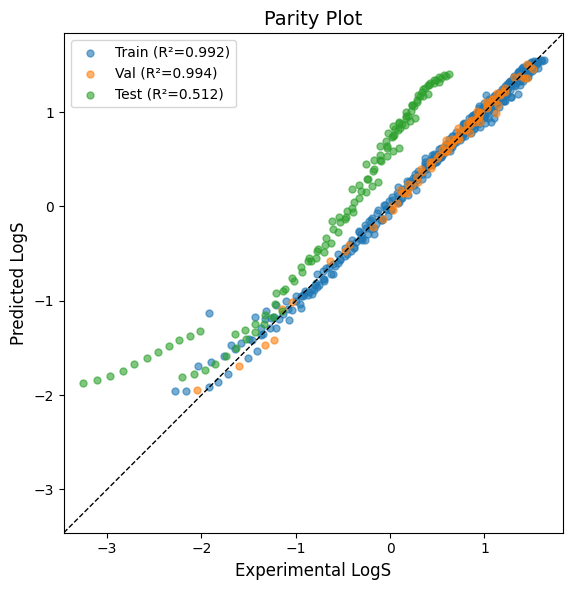

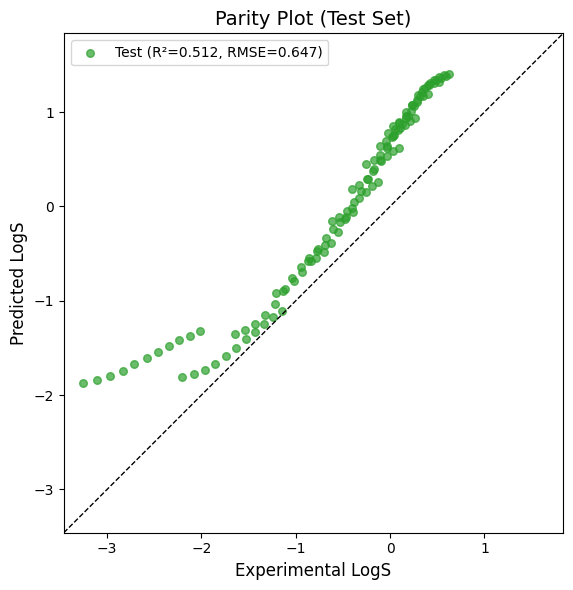


[Mordred Pure NN - Water + 2-Propanol] Train | R²=0.9923 RMSE=0.0722, MAE=0.0466
[Mordred Pure NN - Water + 2-Propanol] Val   | R²=0.9940 RMSE=0.0546, MAE=0.0425
[Mordred Pure NN - Water + 2-Propanol] Test  | R²=0.5123 RMSE=0.6468, MAE=0.5811


In [27]:
# ============================================================================
# Plotting for Mordred Pure NN — Water + 2-Propanol Solvent Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from rdkit import Chem

# ── Load Mordred Pure NN (solvent split) model and scalers ──────────────
checkpoint_mordred_solv = torch.load('mordred_pure_nn_water_ipa_split_model.pt')

mordred_pure_nn_water_ipa_loaded = SolubilityPureNNModel(**checkpoint_mordred_solv['model_config'])
mordred_pure_nn_water_ipa_loaded.load_state_dict(checkpoint_mordred_solv['model_state_dict'])
mordred_pure_nn_water_ipa_loaded.eval()

with open('mordred_pure_nn_water_ipa_split_scalers.pkl', 'rb') as f:
    scalers_mordred_solv = pickle.load(f)
scaler_fp_water_ipa_loaded = scalers_mordred_solv['scaler_fp']
scaler_comp_water_ipa_loaded = scalers_mordred_solv['scaler_comp']
scaler_temp_water_ipa_loaded = scalers_mordred_solv['scaler_temp']

print("Loaded mordred_pure_nn_water_ipa_split_model and scalers")

# ── Recreate the solvent split indices ──────────────────────────────────────
WATER_SMILES = "O"
ISOPROPANOL_SMILES = "CC(C)O"

def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None

water_canon = canon(WATER_SMILES)
ipa_canon = canon(ISOPROPANOL_SMILES)

df['_smiles1_canon'] = df['SMILES_1'].apply(canon)
df['_smiles2_canon'] = df['SMILES_2'].apply(canon)

mask_solv_test = (
    ((df['_smiles1_canon'] == water_canon) & (df['_smiles2_canon'] == ipa_canon)) |
    ((df['_smiles1_canon'] == ipa_canon) & (df['_smiles2_canon'] == water_canon))
)

idx_solv_test = df.index[mask_solv_test].values
idx_solv_remain = df.index[~mask_solv_test].values
idx_solv_train, idx_solv_val = train_test_split(idx_solv_remain, test_size=0.15, random_state=42)

print(f"Recreated solvent split -> Train: {len(idx_solv_train)} | Val: {len(idx_solv_val)} | Test: {len(idx_solv_test)}")

# ── Rebuild full arrays from dataframe ──────────────────────────────────────
T_full = df['Temperature (K)'].values.reshape(-1, 1)
Y_full = df['LogS'].values.reshape(-1, 1)

# ── Scale features using the LOADED scalers ─────────────────────────────────
X_fp_scaled = scaler_fp_water_ipa_loaded.transform(X_fp)
x1_scaled = scaler_comp_water_ipa_loaded.transform(x1)
T_scaled = scaler_temp_water_ipa_loaded.transform(T_full)

def to_t(arr): return torch.tensor(arr, dtype=torch.float32)

# ── Create tensors for Mordred Pure NN ─────────────────────────────────────
X_fp_train_t, x1_train_t, T_train_t, Y_train_t = map(
    to_t, [X_fp_scaled[idx_solv_train], x1_scaled[idx_solv_train], T_scaled[idx_solv_train], Y_full[idx_solv_train]]
)
X_fp_val_t, x1_val_t, T_val_t, Y_val_t = map(
    to_t, [X_fp_scaled[idx_solv_val], x1_scaled[idx_solv_val], T_scaled[idx_solv_val], Y_full[idx_solv_val]]
)
X_fp_test_t, x1_test_t, T_test_t, Y_test_t = map(
    to_t, [X_fp_scaled[idx_solv_test], x1_scaled[idx_solv_test], T_scaled[idx_solv_test], Y_full[idx_solv_test]]
)

# ── Get Mordred Pure NN predictions ────────────────────────────────────────
mordred_pure_nn_water_ipa_loaded.eval()
with torch.no_grad():
    Y_pred_train = mordred_pure_nn_water_ipa_loaded(X_fp_train_t, x1_train_t, T_train_t).numpy().flatten()
    Y_pred_val   = mordred_pure_nn_water_ipa_loaded(X_fp_val_t,   x1_val_t,   T_val_t).numpy().flatten()
    Y_pred_test  = mordred_pure_nn_water_ipa_loaded(X_fp_test_t,  x1_test_t,  T_test_t).numpy().flatten()

Y_train_np = Y_train_t.numpy().flatten()
Y_val_np   = Y_val_t.numpy().flatten()
Y_test_np  = Y_test_t.numpy().flatten()

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(Y_train_np, Y_pred_train)
r2_val,   rmse_val   = get_metrics(Y_val_np,   Y_pred_val)
r2_test,  rmse_test  = get_metrics(Y_test_np,  Y_pred_test)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([Y_train_np, Y_val_np, Y_test_np])
all_pred = np.concatenate([Y_pred_train, Y_pred_val, Y_pred_test])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_train_np, Y_pred_train, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(Y_val_np,   Y_pred_val,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(Y_test_np,  Y_pred_test,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=12)
plt.ylabel('Predicted LogS', fontsize=12)
plt.title('Parity Plot', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(Y_test_np, Y_pred_test, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=12)
plt.ylabel('Predicted LogS', fontsize=12)
plt.title('Parity Plot (Test Set)', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[Mordred Pure NN - Water + 2-Propanol] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(Y_train_np - Y_pred_train)):.4f}")
print(f"[Mordred Pure NN - Water + 2-Propanol] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(Y_val_np - Y_pred_val)):.4f}")
print(f"[Mordred Pure NN - Water + 2-Propanol] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(Y_test_np - Y_pred_test)):.4f}")

Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_pure_nn_water_ipa_split_model and scalers
Recreated solvent split -> Train: 478 | Val: 85 | Test: 121
Dataset size: 478 samples
Dataset size: 85 samples
Dataset size: 121 samples


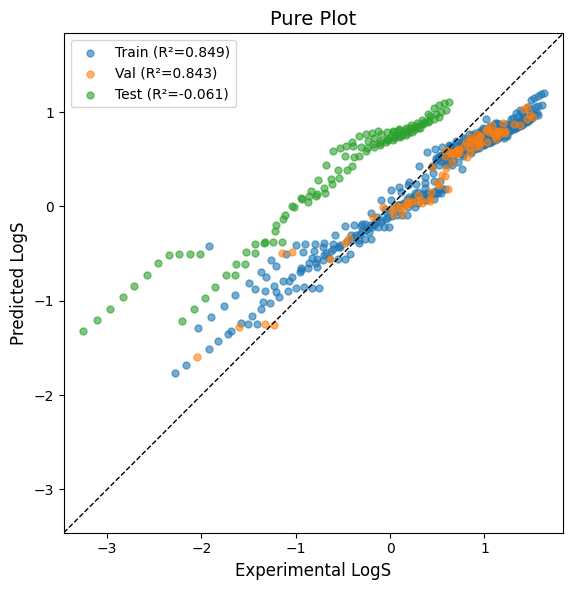

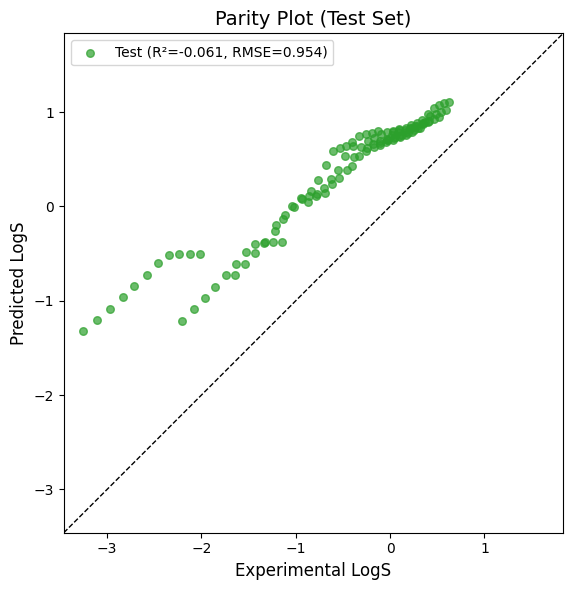


[ChemBERTa Pure NN - Water + 2-Propanol] Train | R²=0.8486 RMSE=0.3204, MAE=0.2722
[ChemBERTa Pure NN - Water + 2-Propanol] Val   | R²=0.8433 RMSE=0.2793, MAE=0.2404
[ChemBERTa Pure NN - Water + 2-Propanol] Test  | R²=-0.0608 RMSE=0.9539, MAE=0.8885


In [26]:
# ============================================================================
# Plotting for ChemBERTa Pure NN — Water + 2-Propanol Solvent Split (loaded from saved checkpoint)
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from rdkit import Chem

# ── Load ChemBERTa Pure NN (solvent split) model and scaler ──────────────
checkpoint_chemberta_solv = torch.load('chemberta_pure_nn_water_ipa_split_model.pt', map_location=DEVICE)

chemberta_pure_nn_water_ipa_loaded = FineTunedChemBERTa(**checkpoint_chemberta_solv['model_config']).to(DEVICE)
chemberta_pure_nn_water_ipa_loaded.load_state_dict(checkpoint_chemberta_solv['model_state_dict'])
chemberta_pure_nn_water_ipa_loaded.eval()

with open('chemberta_pure_nn_water_ipa_split_scalers.pkl', 'rb') as f:
    scalers_chem_solv = pickle.load(f)
scaler_temp_chem_water_ipa_loaded = scalers_chem_solv['scaler_temp']

print("Loaded chemberta_pure_nn_water_ipa_split_model and scalers")

# ── Recreate the solvent split indices ──────────────────────────────────────
WATER_SMILES = "O"
ISOPROPANOL_SMILES = "CC(C)O"

def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None

water_canon = canon(WATER_SMILES)
ipa_canon = canon(ISOPROPANOL_SMILES)

df['_smiles1_canon'] = df['SMILES_1'].apply(canon)
df['_smiles2_canon'] = df['SMILES_2'].apply(canon)

mask_solv_test = (
    ((df['_smiles1_canon'] == water_canon) & (df['_smiles2_canon'] == ipa_canon)) |
    ((df['_smiles1_canon'] == ipa_canon) & (df['_smiles2_canon'] == water_canon))
)

idx_solv_test = df.index[mask_solv_test].values
idx_solv_remain = df.index[~mask_solv_test].values
idx_solv_train, idx_solv_val = train_test_split(idx_solv_remain, test_size=0.15, random_state=42)

print(f"Recreated solvent split -> Train: {len(idx_solv_train)} | Val: {len(idx_solv_val)} | Test: {len(idx_solv_test)}")

# ── Recreate datasets for ChemBERTa ──────────────────────────────────────────
train_df_solv_chem = df.loc[idx_solv_train]
val_df_solv_chem   = df.loc[idx_solv_val]
test_df_solv_chem  = df.loc[idx_solv_test]

# Use the loaded ChemBERTa temperature scaler
chem_train_dataset_solv = SolubilityDataset(train_df_solv_chem, temp_scaler=scaler_temp_chem_water_ipa_loaded)
chem_val_dataset_solv   = SolubilityDataset(val_df_solv_chem,   temp_scaler=scaler_temp_chem_water_ipa_loaded)
chem_test_dataset_solv  = SolubilityDataset(test_df_solv_chem,  temp_scaler=scaler_temp_chem_water_ipa_loaded)

chem_train_loader_solv = DataLoader(chem_train_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_val_loader_solv   = DataLoader(chem_val_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_solv  = DataLoader(chem_test_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)

# ── Get ChemBERTa Pure NN predictions ──────────────────────────────────────
chemberta_pure_nn_water_ipa_loaded.eval()

# Train predictions
train_preds, train_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_pure_nn_water_ipa_loaded(smiles1, smiles2, comp1, T_batch)
        train_preds.extend(predictions.squeeze().cpu().numpy())
        train_targets.extend(y.numpy())

# Val predictions
val_preds, val_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_val_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_pure_nn_water_ipa_loaded(smiles1, smiles2, comp1, T_batch)
        val_preds.extend(predictions.squeeze().cpu().numpy())
        val_targets.extend(y.numpy())

# Test predictions
test_preds, test_targets = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_pure_nn_water_ipa_loaded(smiles1, smiles2, comp1, T_batch)
        test_preds.extend(predictions.squeeze().cpu().numpy())
        test_targets.extend(y.numpy())

train_preds = np.array(train_preds)
train_targets = np.array(train_targets)
val_preds = np.array(val_preds)
val_targets = np.array(val_targets)
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

def get_metrics(y_true, y_pred):
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    return r2, rmse

r2_train, rmse_train = get_metrics(train_targets, train_preds)
r2_val,   rmse_val   = get_metrics(val_targets,   val_preds)
r2_test,  rmse_test  = get_metrics(test_targets,  test_preds)

# ── Common axis limits (shared by both plots for fair visual comparison) ───
all_true = np.concatenate([train_targets, val_targets, test_targets])
all_pred = np.concatenate([train_preds, val_preds, test_preds])
lims = [min(all_true.min(), all_pred.min()) - 0.2, max(all_true.max(), all_pred.max()) + 0.2]

# ============================================================================
# Plot 1 — Train + Val + Test together, color-coded
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(train_targets, train_preds, alpha=0.6, s=25, color='tab:blue',   label=f'Train (R²={r2_train:.3f})')
plt.scatter(val_targets,   val_preds,   alpha=0.6, s=25, color='tab:orange', label=f'Val (R²={r2_val:.3f})')
plt.scatter(test_targets,  test_preds,  alpha=0.6, s=25, color='tab:green',  label=f'Test (R²={r2_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=12)
plt.ylabel('Predicted LogS', fontsize=12)
plt.title('Pure Plot', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# ============================================================================
# Plot 2 — Test set only
# ============================================================================
plt.figure(figsize=(6, 6))
plt.scatter(test_targets, test_preds, alpha=0.7, s=30, color='tab:green',
            label=f'Test (R²={r2_test:.3f}, RMSE={rmse_test:.3f})')
plt.plot(lims, lims, 'k--', linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Experimental LogS', fontsize=12)
plt.ylabel('Predicted LogS', fontsize=12)
plt.title('Parity Plot (Test Set)', fontsize=14)
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

print(f"\n[ChemBERTa Pure NN - Water + 2-Propanol] Train | R²={r2_train:.4f} RMSE={rmse_train:.4f}, MAE={np.mean(np.abs(train_targets - train_preds)):.4f}")
print(f"[ChemBERTa Pure NN - Water + 2-Propanol] Val   | R²={r2_val:.4f} RMSE={rmse_val:.4f}, MAE={np.mean(np.abs(val_targets - val_preds)):.4f}")
print(f"[ChemBERTa Pure NN - Water + 2-Propanol] Test  | R²={r2_test:.4f} RMSE={rmse_test:.4f}, MAE={np.mean(np.abs(test_targets - test_preds)):.4f}")

Rows found for Toluene + Acetone pair: 63
Solvent-pair split -> Train: 527 | Val: 94 | Test: 63
[Solvent split/Mordred] Train: 527 | Val: 94 | Test: 63
[Solvent split/Mordred] Total trainable parameters: 874625
[Solvent split/Mordred] Epoch   50 | Train: 0.1847 | Val: 0.0339
[Solvent split/Mordred] Epoch  100 | Train: 0.1406 | Val: 0.0185
[Solvent split/Mordred] Epoch  150 | Train: 0.1544 | Val: 0.0131
[Solvent split/Mordred] Epoch  200 | Train: 0.1530 | Val: 0.0113
[Solvent split/Mordred] Epoch  250 | Train: 0.1256 | Val: 0.0087
[Solvent split/Mordred] Early stopping at epoch 293

[Solvent split/Mordred] Best val loss: 0.0078
[Solvent split/Mordred] Train | R²=0.9899 RMSE=0.0953 MAE=0.0618
[Solvent split/Mordred] Test  | R²=-0.4165 RMSE=0.1663 MAE=0.1141
Dataset size: 527 samples
Dataset size: 94 samples
Dataset size: 63 samples
[Solvent split/ChemBERTa] Train: 527 | Val: 94 | Test: 63
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
[Solvent split/ChemBERTa] Total trainable pa

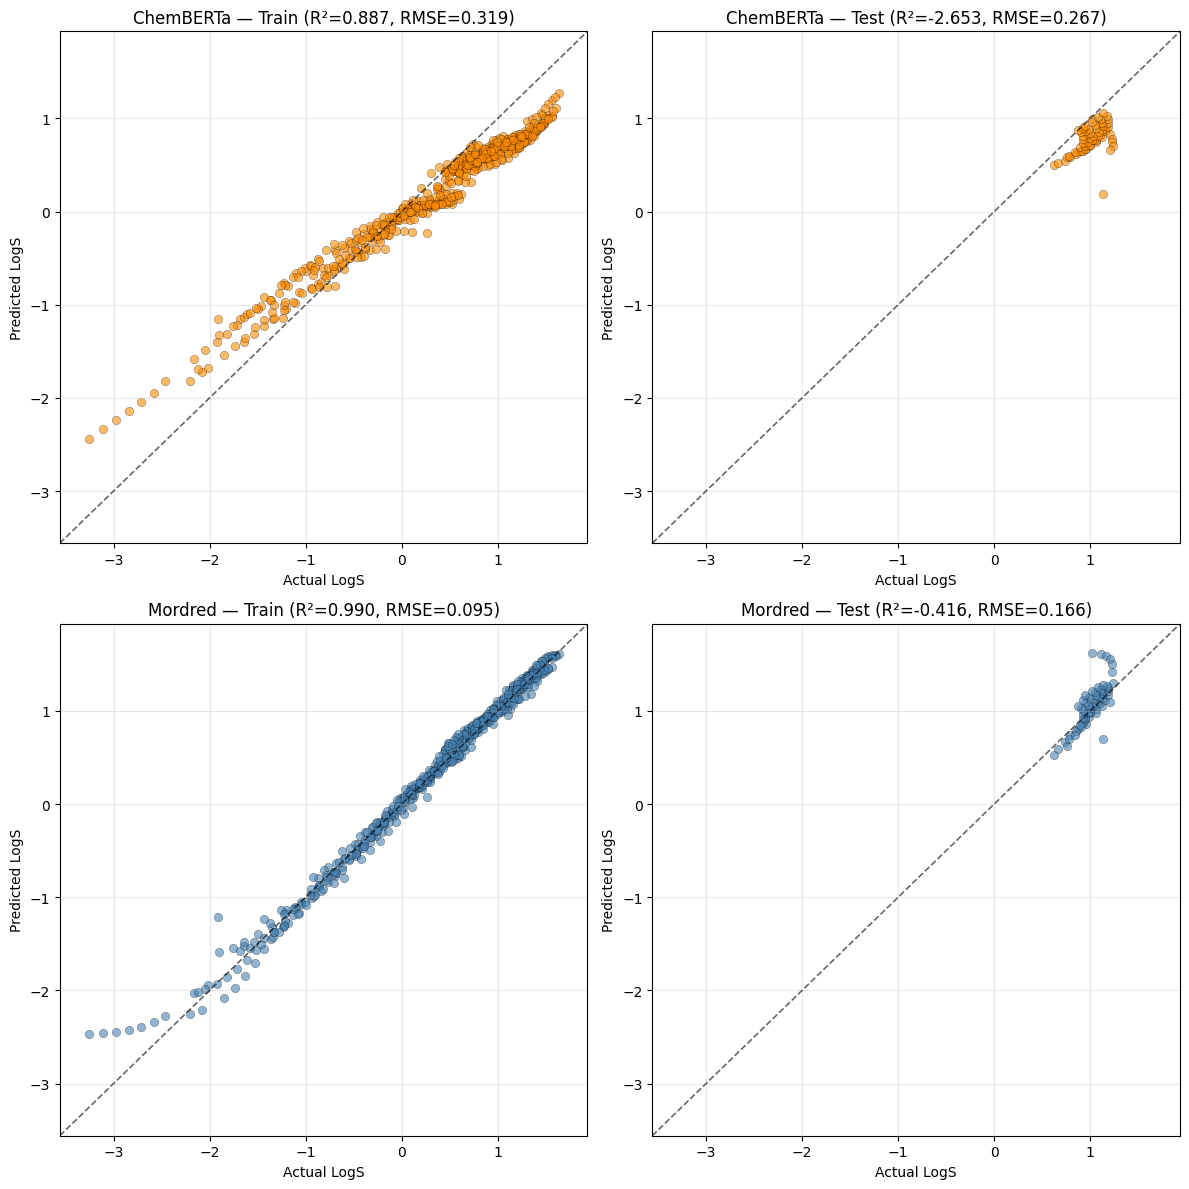

In [25]:
# ============================================================================
# SOLVENT-PAIR-BASED SPLIT — holds out toluene + acetone
# ============================================================================
TOLUENE_SMILES = "C=1C=CC(=CC1)C"
ACETONE_SMILES = "O=C(C)C"

def canon(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None

toluene_canon = canon(TOLUENE_SMILES)
acetone_canon = canon(ACETONE_SMILES)

df['_smiles1_canon'] = df['SMILES_1'].apply(canon)
df['_smiles2_canon'] = df['SMILES_2'].apply(canon)

mask_solv_test = (
    ((df['_smiles1_canon'] == toluene_canon) & (df['_smiles2_canon'] == acetone_canon)) |
    ((df['_smiles1_canon'] == acetone_canon) & (df['_smiles2_canon'] == toluene_canon))
)

idx_solv_test = df.index[mask_solv_test].values
idx_solv_remain = df.index[~mask_solv_test].values

print(f"Rows found for Toluene + Acetone pair: {len(idx_solv_test)}")
if len(idx_solv_test) == 0:
    print("WARNING: no rows matched — check that this solvent pair actually exists in the dataset.")
    print(df[['SMILES_1', 'SMILES_2']].drop_duplicates().to_string())

idx_solv_train, idx_solv_val = train_test_split(idx_solv_remain, test_size=0.15, random_state=42)
print(f"Solvent-pair split -> Train: {len(idx_solv_train)} | Val: {len(idx_solv_val)} | Test: {len(idx_solv_test)}")

df.drop(columns=['_smiles1_canon', '_smiles2_canon'], inplace=True)

# ---- MORDRED: solvent-pair split ----
scaler_fp_solv = StandardScaler().fit(X_fp[idx_solv_train])
scaler_comp_solv = StandardScaler().fit(x1[idx_solv_train])
scaler_temp_solv = StandardScaler().fit(T[idx_solv_train])

X_fp_train_solv = scaler_fp_solv.transform(X_fp[idx_solv_train])
X_fp_val_solv   = scaler_fp_solv.transform(X_fp[idx_solv_val])
X_fp_test_solv  = scaler_fp_solv.transform(X_fp[idx_solv_test])

x1_train_solv = scaler_comp_solv.transform(x1[idx_solv_train])
x1_val_solv   = scaler_comp_solv.transform(x1[idx_solv_val])
x1_test_solv  = scaler_comp_solv.transform(x1[idx_solv_test])

T_train_solv = scaler_temp_solv.transform(T[idx_solv_train])
T_val_solv   = scaler_temp_solv.transform(T[idx_solv_val])
T_test_solv  = scaler_temp_solv.transform(T[idx_solv_test])

Y_train_solv, Y_val_solv, Y_test_solv = Y[idx_solv_train], Y[idx_solv_val], Y[idx_solv_test]

print(f"[Solvent split/Mordred] Train: {len(X_fp_train_solv)} | Val: {len(X_fp_val_solv)} | Test: {len(X_fp_test_solv)}")

X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t = map(
    to_t, [X_fp_train_solv, x1_train_solv, T_train_solv, Y_train_solv])
X_fp_val_solv_t, x1_val_solv_t, T_val_solv_t, Y_val_solv_t = map(
    to_t, [X_fp_val_solv, x1_val_solv, T_val_solv, Y_val_solv])
X_fp_test_solv_t, x1_test_solv_t, T_test_solv_t, Y_test_solv_t = map(
    to_t, [X_fp_test_solv, x1_test_solv, T_test_solv, Y_test_solv])

train_ds_solv = TensorDataset(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t, Y_train_solv_t)
val_ds_solv   = TensorDataset(X_fp_val_solv_t,   x1_val_solv_t,   T_val_solv_t,   Y_val_solv_t)
test_ds_solv  = TensorDataset(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t,  Y_test_solv_t)

train_loader_solv = DataLoader(train_ds_solv, batch_size=32, shuffle=True)
val_loader_solv   = DataLoader(val_ds_solv,   batch_size=len(val_ds_solv),  shuffle=False)
test_loader_solv  = DataLoader(test_ds_solv,  batch_size=len(test_ds_solv), shuffle=False)

mordred_model_solv = SolubilityPureNNModel(
    n_fp_features=X_fp.shape[1],
    fp_emb_hidden_layers=[512, 256, 128], fp_emb_dropout=0.2, fp_emb_actfunc='Tanh', fp_emb_size=64,
    n_comp_features=1, comp_emb_hidden_layers=[16, 16], comp_emb_dropout=0.1, comp_emb_actfunc='Tanh', comp_emb_size=16,
    n_temp_features=1, temp_emb_hidden_layers=[16, 16], temp_emb_dropout=0.1, temp_emb_actfunc='Tanh', temp_emb_size=16,
    out_hidden_layers=[32], out_dropout=0.1, out_actfunc='Tanh',
)
print(f"[Solvent split/Mordred] Total trainable parameters: {mordred_model_solv.count_parameters()}")

optimizer_solv = torch.optim.Adam(mordred_model_solv.parameters(), lr=1e-3)
criterion = nn.MSELoss()

MAX_EPOCHS, PATIENCE = 600, 50
best_val_loss_solv, patience_counter_solv, best_weights_solv = float('inf'), 0, None
train_losses_solv, val_losses_solv = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    mordred_model_solv.train()
    epoch_train_loss = 0.0
    for X_fp_b, x1_b, T_b, Y_b in train_loader_solv:
        optimizer_solv.zero_grad()
        Y_pred = mordred_model_solv(X_fp_b, x1_b, T_b)
        loss = criterion(Y_pred, Y_b)
        loss.backward()
        optimizer_solv.step()
        epoch_train_loss += loss.item() * len(X_fp_b)
    epoch_train_loss /= len(train_ds_solv)

    mordred_model_solv.eval()
    with torch.no_grad():
        for X_fp_b, x1_b, T_b, Y_b in val_loader_solv:
            epoch_val_loss = criterion(mordred_model_solv(X_fp_b, x1_b, T_b), Y_b).item()

    train_losses_solv.append(epoch_train_loss)
    val_losses_solv.append(epoch_val_loss)

    if epoch_val_loss < best_val_loss_solv:
        best_val_loss_solv = epoch_val_loss
        best_weights_solv = {k: v.clone() for k, v in mordred_model_solv.state_dict().items()}
        patience_counter_solv = 0
    else:
        patience_counter_solv += 1
        if patience_counter_solv >= PATIENCE:
            print(f"[Solvent split/Mordred] Early stopping at epoch {epoch}")
            break

    if epoch % 50 == 0:
        print(f"[Solvent split/Mordred] Epoch {epoch:4d} | Train: {epoch_train_loss:.4f} | Val: {epoch_val_loss:.4f}")

mordred_model_solv.load_state_dict(best_weights_solv)
print(f"\n[Solvent split/Mordred] Best val loss: {best_val_loss_solv:.4f}")

mordred_model_solv.eval()
with torch.no_grad():
    Y_pred_train_mordred_solv = mordred_model_solv(X_fp_train_solv_t, x1_train_solv_t, T_train_solv_t).numpy().flatten()
    Y_pred_test_mordred_solv  = mordred_model_solv(X_fp_test_solv_t,  x1_test_solv_t,  T_test_solv_t).numpy().flatten()

Y_train_np_solv = Y_train_solv_t.numpy().flatten()
Y_test_np_solv  = Y_test_solv_t.numpy().flatten()

r2_train_m_solv, rmse_train_m_solv, mae_train_m_solv = get_metrics(Y_train_np_solv, Y_pred_train_mordred_solv)
r2_test_m_solv,  rmse_test_m_solv,  mae_test_m_solv  = get_metrics(Y_test_np_solv,  Y_pred_test_mordred_solv)

print(f"[Solvent split/Mordred] Train | R²={r2_train_m_solv:.4f} RMSE={rmse_train_m_solv:.4f} MAE={mae_train_m_solv:.4f}")
print(f"[Solvent split/Mordred] Test  | R²={r2_test_m_solv:.4f} RMSE={rmse_test_m_solv:.4f} MAE={mae_test_m_solv:.4f}")

# ---- CHEMBERTA: solvent-pair split ----
train_df_solv_chem = df.loc[idx_solv_train]
val_df_solv_chem   = df.loc[idx_solv_val]
test_df_solv_chem  = df.loc[idx_solv_test]

scaler_temp_chem_solv = StandardScaler().fit(train_df_solv_chem['Temperature (K)'].values.reshape(-1, 1))
chem_train_dataset_solv = SolubilityDataset(train_df_solv_chem, temp_scaler=scaler_temp_chem_solv)
chem_val_dataset_solv   = SolubilityDataset(val_df_solv_chem,   temp_scaler=scaler_temp_chem_solv)
chem_test_dataset_solv  = SolubilityDataset(test_df_solv_chem,  temp_scaler=scaler_temp_chem_solv)

chem_train_loader_solv = DataLoader(chem_train_dataset_solv, batch_size=32, shuffle=True, collate_fn=collate_fn)
chem_val_loader_solv   = DataLoader(chem_val_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)
chem_test_loader_solv  = DataLoader(chem_test_dataset_solv, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"[Solvent split/ChemBERTa] Train: {len(chem_train_dataset_solv)} | Val: {len(chem_val_dataset_solv)} | Test: {len(chem_test_dataset_solv)}")

chemberta_model_solv = FineTunedChemBERTa(
    model_name="seyonec/ChemBERTa-zinc-base-v1",
    mix_emb_hidden_layers=[512, 256], mix_emb_dropout=0.3, mix_emb_actfunc='ReLU', mix_emb_size=128,
    temp_emb_hidden_layers=[16, 16], temp_emb_dropout=0.1, temp_emb_actfunc='ReLU', temp_emb_size=16,
    out_hidden_layers=[64, 32], out_dropout=0.2, out_actfunc='ReLU'
).to(DEVICE)
print(f"[Solvent split/ChemBERTa] Total trainable parameters: {chemberta_model_solv.count_parameters():,}")

print("\n[Solvent split/ChemBERTa] STAGE 1: Training MLP heads only (frozen)")
chemberta_model_solv.freeze_chemberta()
train_losses_1_solv, val_losses_1_solv, r2_scores_1_solv, best_val_loss_c_solv, best_weights_c_solv = train_model(
    chemberta_model_solv, chem_train_loader_solv, chem_val_loader_solv,
    epochs=50, lr=0.001, device=DEVICE, stage_name="[Solvent split] Stage 1"
)

print("\n[Solvent split/ChemBERTa] STAGE 2: Fine-tuning (unfrozen)")
chemberta_model_solv.unfreeze_chemberta(unfreeze_layers=4)
train_losses_2_solv, val_losses_2_solv, r2_scores_2_solv, best_val_loss_c_solv, best_weights_c_solv = train_model(
    chemberta_model_solv, chem_train_loader_solv, chem_val_loader_solv,
    epochs=30, lr=0.0001, device=DEVICE, stage_name="[Solvent split] Stage 2",
    best_val_loss=best_val_loss_c_solv, best_weights=best_weights_c_solv
)

chemberta_model_solv.load_state_dict(best_weights_c_solv)
print(f"\n[Solvent split/ChemBERTa] Loaded best checkpoint (val loss = {best_val_loss_c_solv:.4f})")

chemberta_model_solv.eval()
test_preds_c_solv, test_targets_c_solv = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_test_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_solv(smiles1, smiles2, comp1, T_batch)
        test_preds_c_solv.extend(predictions.squeeze().cpu().numpy())
        test_targets_c_solv.extend(y.numpy())

test_preds_c_solv, test_targets_c_solv = np.array(test_preds_c_solv), np.array(test_targets_c_solv)
r2_c_solv, rmse_c_solv, mae_c_solv = get_metrics(test_targets_c_solv, test_preds_c_solv)
print(f"[Solvent split/ChemBERTa] Test | R²={r2_c_solv:.4f} RMSE={rmse_c_solv:.4f} MAE={mae_c_solv:.4f}")

train_preds_c_solv, train_targets_c_solv = [], []
with torch.no_grad():
    for smiles1, smiles2, comp1, T_batch, y, orig_idx in chem_train_loader_solv:
        comp1, T_batch = comp1.to(DEVICE), T_batch.to(DEVICE)
        predictions = chemberta_model_solv(smiles1, smiles2, comp1, T_batch)
        train_preds_c_solv.extend(predictions.squeeze().cpu().numpy())
        train_targets_c_solv.extend(y.numpy())

train_preds_c_solv, train_targets_c_solv = np.array(train_preds_c_solv), np.array(train_targets_c_solv)
r2_train_c_solv, rmse_train_c_solv, mae_train_c_solv = get_metrics(train_targets_c_solv, train_preds_c_solv)
print(f"[Solvent split/ChemBERTa] Train | R²={r2_train_c_solv:.4f} RMSE={rmse_train_c_solv:.4f} MAE={mae_train_c_solv:.4f}")

# ---- 2x2 comparison: solvent-pair split ----
print("\n" + "="*60)
print("COMPARISON — Solvent-Pair-BASED SPLIT (Toluene + Acetone held out)")
print("="*60)
print(f"{'Model':<12}{'Set':<8}{'R²':>10}{'RMSE':>10}{'MAE':>10}")
print(f"{'ChemBERTa':<12}{'Train':<8}{r2_train_c_solv:>10.4f}{rmse_train_c_solv:>10.4f}{mae_train_c_solv:>10.4f}")
print(f"{'ChemBERTa':<12}{'Test':<8}{r2_c_solv:>10.4f}{rmse_c_solv:>10.4f}{mae_c_solv:>10.4f}")
print(f"{'Mordred':<12}{'Train':<8}{r2_train_m_solv:>10.4f}{rmse_train_m_solv:>10.4f}{mae_train_m_solv:>10.4f}")
print(f"{'Mordred':<12}{'Test':<8}{r2_test_m_solv:>10.4f}{rmse_test_m_solv:>10.4f}{mae_test_m_solv:>10.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

all_vals_solv = np.concatenate([
    train_targets_c_solv, train_preds_c_solv, test_targets_c_solv, test_preds_c_solv,
    Y_train_np_solv, Y_pred_train_mordred_solv, Y_test_np_solv, Y_pred_test_mordred_solv
])
lims_solv = [all_vals_solv.min() - 0.3, all_vals_solv.max() + 0.3]

plot_specs_solv = [
    (0, 0, train_targets_c_solv, train_preds_c_solv, 'darkorange', 'ChemBERTa', 'Train', r2_train_c_solv, rmse_train_c_solv),
    (0, 1, test_targets_c_solv,  test_preds_c_solv,  'darkorange', 'ChemBERTa', 'Test',  r2_c_solv,        rmse_c_solv),
    (1, 0, Y_train_np_solv,      Y_pred_train_mordred_solv, 'steelblue', 'Mordred', 'Train', r2_train_m_solv, rmse_train_m_solv),
    (1, 1, Y_test_np_solv,       Y_pred_test_mordred_solv,  'steelblue', 'Mordred', 'Test',  r2_test_m_solv,  rmse_test_m_solv),
]

for row, col, y_true, y_pred, color, model_name, set_name, r2, rmse in plot_specs_solv:
    ax = axes[row, col]
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors='k', linewidths=0.3)
    ax.plot(lims_solv, lims_solv, 'k--', lw=1.2, alpha=0.6)
    ax.set_xlim(lims_solv); ax.set_ylim(lims_solv)
    ax.set_xlabel('Actual LogS'); ax.set_ylabel('Predicted LogS')
    ax.set_title(f'{model_name} — {set_name} (R²={r2:.3f}, RMSE={rmse:.3f})')
    ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('mordred_vs_chemberta_comparison_2x2_solv_split_pureNN.png', dpi=150)
plt.show()

In [26]:
# ── Save Mordred Pure NN (toluene + acetone split) model + scalers ─────────
torch.save({
    'model_state_dict': mordred_model_solv.state_dict(),
    'model_config': {
        'n_fp_features': X_fp.shape[1],
        'fp_emb_hidden_layers': [512, 256, 128], 'fp_emb_dropout': 0.2, 'fp_emb_actfunc': 'Tanh', 'fp_emb_size': 64,
        'n_comp_features': 1, 'comp_emb_hidden_layers': [16, 16], 'comp_emb_dropout': 0.1, 'comp_emb_actfunc': 'Tanh', 'comp_emb_size': 16,
        'n_temp_features': 1, 'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'Tanh', 'temp_emb_size': 16,
        'out_hidden_layers': [32], 'out_dropout': 0.1, 'out_actfunc': 'Tanh',
    }
}, 'mordred_pure_nn_toluene_acetone_split_model.pt')

with open('mordred_pure_nn_toluene_acetone_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_fp': scaler_fp_solv, 'scaler_comp': scaler_comp_solv, 'scaler_temp': scaler_temp_solv}, f)

print("Saved model to 'mordred_pure_nn_toluene_acetone_split_model.pt' and scalers to 'mordred_pure_nn_toluene_acetone_split_scalers.pkl'")

# ── Save ChemBERTa Pure NN (toluene + acetone split) model + scaler ────────
torch.save({
    'model_state_dict': chemberta_model_solv.state_dict(),
    'model_config': {
        'model_name': "seyonec/ChemBERTa-zinc-base-v1",
        'mix_emb_hidden_layers': [512, 256], 'mix_emb_dropout': 0.3, 'mix_emb_actfunc': 'ReLU', 'mix_emb_size': 128,
        'temp_emb_hidden_layers': [16, 16], 'temp_emb_dropout': 0.1, 'temp_emb_actfunc': 'ReLU', 'temp_emb_size': 16,
        'out_hidden_layers': [64, 32], 'out_dropout': 0.2, 'out_actfunc': 'ReLU',
    }
}, 'chemberta_pure_nn_toluene_acetone_split_model.pt')

with open('chemberta_pure_nn_toluene_acetone_split_scalers.pkl', 'wb') as f:
    pickle.dump({'scaler_temp': scaler_temp_chem_solv}, f)

print("Saved model to 'chemberta_pure_nn_toluene_acetone_split_model.pt' and scalers to 'chemberta_pure_nn_toluene_acetone_split_scalers.pkl'")


Saved model to 'mordred_pure_nn_toluene_acetone_split_model.pt' and scalers to 'mordred_pure_nn_toluene_acetone_split_scalers.pkl'
Saved model to 'chemberta_pure_nn_toluene_acetone_split_model.pt' and scalers to 'chemberta_pure_nn_toluene_acetone_split_scalers.pkl'


In [27]:
# ============================================================================
# Load models and scalers for inference/plotting (no training required)
# ============================================================================
import pickle

# ── Load Mordred Pure NN (toluene + acetone split) model ────────────────────
checkpoint_mordred_solv = torch.load('mordred_pure_nn_toluene_acetone_split_model.pt')

mordred_pure_nn_toluene_acetone_loaded = SolubilityPureNNModel(**checkpoint_mordred_solv['model_config'])
mordred_pure_nn_toluene_acetone_loaded.load_state_dict(checkpoint_mordred_solv['model_state_dict'])
mordred_pure_nn_toluene_acetone_loaded.eval()

with open('mordred_pure_nn_toluene_acetone_split_scalers.pkl', 'rb') as f:
    scalers_mordred_solv = pickle.load(f)
scaler_fp_toluene_acetone_loaded = scalers_mordred_solv['scaler_fp']
scaler_comp_toluene_acetone_loaded = scalers_mordred_solv['scaler_comp']
scaler_temp_toluene_acetone_loaded = scalers_mordred_solv['scaler_temp']

print("Loaded mordred_pure_nn_toluene_acetone_split_model and scalers — ready for inference/plotting, no training needed.")

# ── Load ChemBERTa Pure NN (toluene + acetone split) model ──────────────────
checkpoint_chemberta_solv = torch.load('chemberta_pure_nn_toluene_acetone_split_model.pt', map_location=DEVICE)

chemberta_pure_nn_toluene_acetone_loaded = FineTunedChemBERTa(**checkpoint_chemberta_solv['model_config']).to(DEVICE)
chemberta_pure_nn_toluene_acetone_loaded.load_state_dict(checkpoint_chemberta_solv['model_state_dict'])
chemberta_pure_nn_toluene_acetone_loaded.eval()

with open('chemberta_pure_nn_toluene_acetone_split_scalers.pkl', 'rb') as f:
    scalers_chem_solv = pickle.load(f)
scaler_temp_chem_toluene_acetone_loaded = scalers_chem_solv['scaler_temp']

print("Loaded chemberta_pure_nn_toluene_acetone_split_model and scalers — ready for inference/plotting, no training needed.")

Loaded mordred_pure_nn_toluene_acetone_split_model and scalers — ready for inference/plotting, no training needed.
Loading ChemBERTa model: seyonec/ChemBERTa-zinc-base-v1
Loaded chemberta_pure_nn_toluene_acetone_split_model and scalers — ready for inference/plotting, no training needed.
